In [1]:
import os
os.environ["PATH"] = "/global/common/software/nersc9/texlive/2024/bin/x86_64-linux:" + os.environ["PATH"]

In [2]:
%matplotlib inline

import importlib.util
import json
import sys
import pickle
from pathlib import Path



In [3]:
import corner
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import torch
from astropy import units as u
from astropy.coordinates import SkyCoord, Galactocentric, ICRS
from numpy.random import PCG64, SeedSequence
from ml_collections import ConfigDict



In [4]:
import time
t0 = time.time(); import sbi_stream; print('sbi_stream:', time.time()-t0)

sbi_stream: 0.0017650127410888672


In [5]:
sys.path.append('/home/tvnguyen/projects/sbi_stream/ella_code/sbi_stream')

import sbi_stream
from sbi_stream.transforms import build_transformation
from sbi_stream.models import NPE, GNNEmbedding, TransformerEmbedding



In [6]:
torch.set_num_threads(8)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', DEVICE)

device: cuda


### Read in the config file and the PS mock data

In [7]:
def json_to_config_dict(json_path: str) -> ConfigDict:
    with open(json_path, "r") as f:
        config_data = json.load(f)
    return ConfigDict(config_data)

config = json_to_config_dict('/global/homes/e/emarin4/scratch/sbi_stream_personal/inference/ella_config_2mil_9d_nocorr_withuncert_newnorm.json')
model_config = config.model.value
pre_transforms_config = config.pre_transforms.value
norm_dict = config.norm_dict.value

features = config.data.value.features
labels = config.data.value.labels
print('features:', features)
print('labels:', labels)
#print('phi1-min:', config.data.value.phi1_min)
#print('phi1-max:', config.features.phi1_max)
phi1_min, phi1_max = -20, 16

features: ['phi1', 'phi2', 'vr', 'pm1', 'pm2', 'dist']
labels: ['log_mass', 'log_scale_radius', 'phi1_impact_today', 'time_impact', 'impact_parameter', 'v_rel_para', 'v_rel_perp', 'angle_pos_at_impact', 'delta_angle']


In [8]:
mock_path = '/global/homes/e/emarin4/scratch/sbi_stream_personal/inference/nbody_mock_829_2000_withuncert.pkl'

#'/global/homes/e/emarin4/scratch/sbi_stream_personal/preprocessed_825_aau_mock_withuncert/data.0.pkl'

#Nbody mock = '/global/homes/e/emarin4/scratch/sbi_stream_personal/inference/nbody_mock_828_2000_withuncert.pkl'

# PS MOCK = '/global/homes/e/emarin4/scratch/sbi_stream_personal/preprocessed_818_aau_mock_withuncert/data.0.pkl'
#'/global/homes/e/emarin4/scratch/sbi_stream_personal/preprocessed_818_9d_500k_nocorr_mocks_withuncert/data.0.pkl'

with open(mock_path, 'rb') as f:
    data = pickle.load(f)

print(data)

truths = torch.stack([d.y.squeeze(0) for d in data]).numpy()

print(truths)

[Data(x=[1794, 9], y=[1, 9], pos=[1794, 2])]
[[  7.90309  -0.60206 -12.5      -0.25      0.5     -10.       65.
    5.        5.     ]]


In [9]:
color_ps = '#0077BB'
color_nbody = '#EE7733'

log_mass: 7.9031
log_scale_radius: -0.6021
phi1_impact_today: -12.5000
time_impact: -0.2500
impact_parameter: 0.5000
v_rel_para: -10.0000
v_rel_perp: 65.0000
angle_pos_at_impact: 5.0000
delta_angle: 5.0000


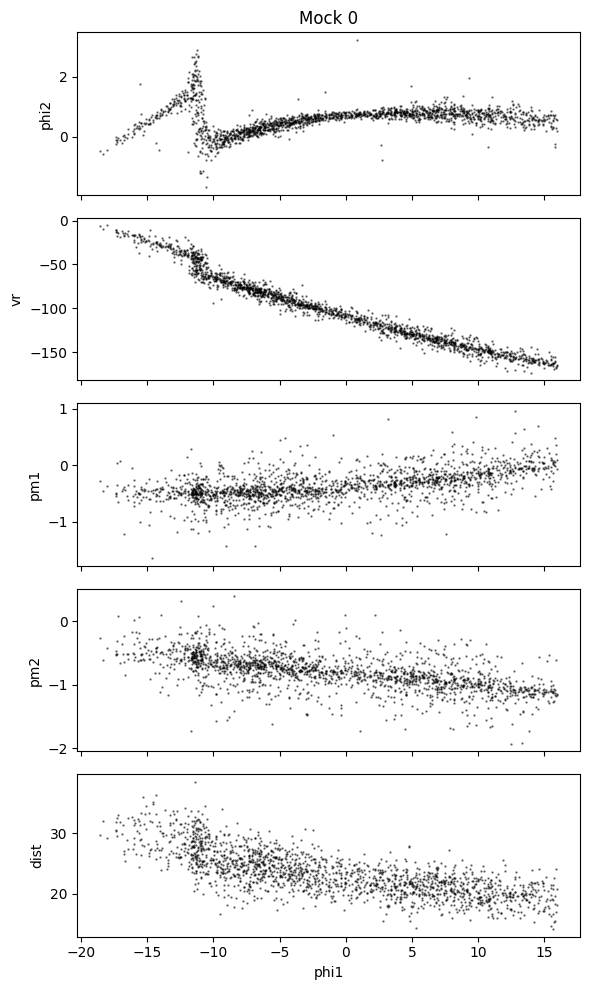

In [10]:
#Looking at 1 mock for testing

labels = ['log_mass', 'log_scale_radius', 'phi1_impact_today', 'time_impact',
          'impact_parameter', 'v_rel_para', 'v_rel_perp',
          'angle_pos_at_impact', 'delta_angle', 'angle_vel_at_impact', 'delta_phi1']

i = 0 #73
d = data[i]

truths = d.y.squeeze(0).numpy()
true_params_dict = dict(zip(labels, truths))

#Look at truths
for l, v in true_params_dict.items():
    print(f"{l}: {v:.4f}")

#Plot the stream
stream = d.x.numpy()   
phi1 = stream[:, 0]

features = ['phi1', 'phi2', 'vr', 'pm1', 'pm2', 'dist']
fig, axes = plt.subplots(5, figsize=(6, 10), sharex=True)
for j, ax in enumerate(axes):
    coord = stream[:, 1 + j]
    ax.scatter(phi1, coord, s=0.5, c='k', alpha=0.5)
    ax.set_ylabel(features[j+1])  
axes[-1].set_xlabel(features[0])
axes[0].set_title(f'Mock {i}')
plt.tight_layout()
plt.show()


log_mass: 7.9031
log_scale_radius: -0.6021
phi1_impact_today: -12.5000
time_impact: -0.2500
impact_parameter: 0.5000
v_rel_para: -10.0000
v_rel_perp: 65.0000
angle_pos_at_impact: 5.0000
delta_angle: 5.0000


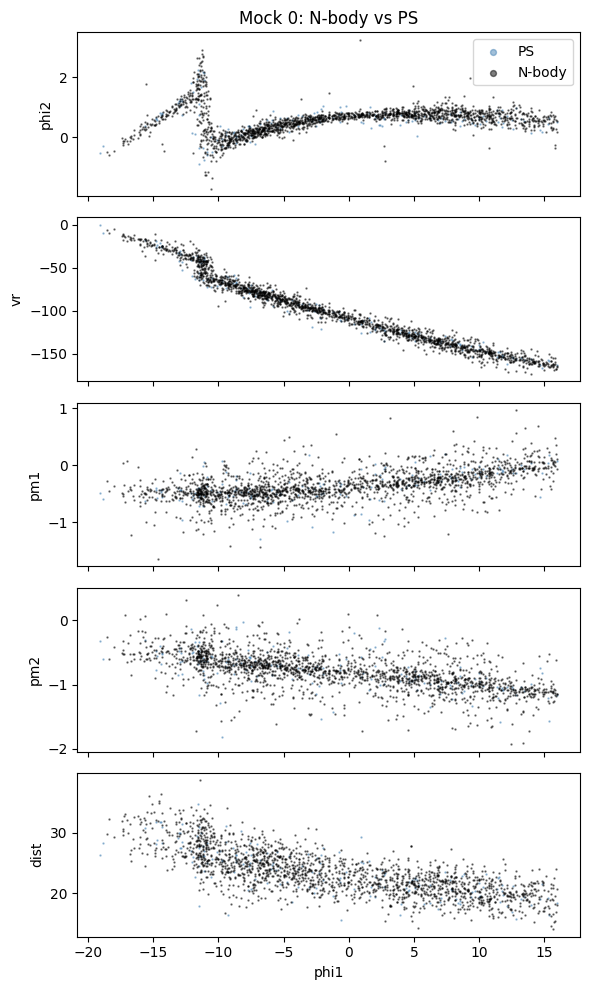

In [11]:
# Load nbody mock
mock_path = '/global/homes/e/emarin4/scratch/sbi_stream_personal/inference/nbody_mock_829_2000_withuncert.pkl'
with open(mock_path, 'rb') as f:
    data_nbody = pickle.load(f)

# Load PS mock
ps_path = '/global/homes/e/emarin4/scratch/sbi_stream_personal/preprocessed_825_aau_mock_withuncert/data.0.pkl'
with open(ps_path, 'rb') as f:
    data_ps = pickle.load(f)

labels = ['log_mass', 'log_scale_radius', 'phi1_impact_today', 'time_impact',
          'impact_parameter', 'v_rel_para', 'v_rel_perp',
          'angle_pos_at_impact', 'delta_angle', 'angle_vel_at_impact', 'delta_phi1']

i = 0
d_nbody = data_nbody[i]
d_ps    = data_ps[i]

truths = d_nbody.y.squeeze(0).numpy()
true_params_dict = dict(zip(labels, truths))
for l, v in true_params_dict.items():
    print(f"{l}: {v:.4f}")

features = ['phi1', 'phi2', 'vr', 'pm1', 'pm2', 'dist']

stream_nbody = d_nbody.x.numpy()
stream_ps    = d_ps.x.numpy()

phi1_nbody = stream_nbody[:, 0]
phi1_ps    = stream_ps[:, 0]

fig, axes = plt.subplots(5, figsize=(6, 10), sharex=True)
for j, ax in enumerate(axes):
    ax.scatter(phi1_ps,    stream_ps[:,    1 + j], s=0.5, c='steelblue', alpha=0.5, label='PS')
    ax.scatter(phi1_nbody, stream_nbody[:, 1 + j], s=0.5, c='k',         alpha=0.5, label='N-body')
    ax.set_ylabel(features[j + 1])

axes[0].legend(markerscale=6, loc='upper right')
axes[-1].set_xlabel(features[0])
axes[0].set_title(f'Mock {i}: N-body vs PS')
plt.tight_layout()
plt.show()

In [14]:
import pandas as pd
plot_pretty(dpi=175, fontsize=15, labelsize=13, figsize=(8, 8), tex=True)

aau_path = '/global/homes/e/emarin4/scratch/training_sims/aau_sbi_fastsims/workspace/vel_disp_test/combined_members_prepared.csv'
aau = pd.read_csv(aau_path)

# Apply same phi1 window
aau_cut = aau[(aau['phi1'] >= phi1_min) & (aau['phi1'] < phi1_max)]

aau_cols = {
    'phi2': 'phi2',
    'vr':   'vel_calib',
    'pm1':  'pm1',
    'pm2':  'pm2',
    'dist': 'distance_kpc',
}

fig, axes = plt.subplots(5, figsize=(6, 10), sharex=True)
for j, ax in enumerate(axes):
    feat = features[j + 1]
    ax.scatter(phi1_ps,                stream_ps[:, 1 + j],          s=0.5,  c='steelblue', alpha=0.5, label='PS')
    #ax.scatter(phi1_nbody,             stream_nbody[:, 1 + j],        s=0.5,  c='k',         alpha=0.5, label='N-body')
    ax.scatter(aau_cut['phi1'].values, aau_cut[aau_cols[feat]].values, s=2,    c='crimson',   alpha=0.9, label='AAU', zorder=5)
    ax.set_ylabel(feat)

axes[0].legend(markerscale=4, loc='upper right')
axes[-1].set_xlabel('phi1')
axes[0].set_title('N-body vs PS vs AAU data')
plt.tight_layout()
plt.show()

NameError: name 'plot_pretty' is not defined

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plot_pretty(dpi=175, fontsize=17, labelsize=15, figsize=(8, 10), tex=True)

aau = pd.read_csv(aau_path)
aau_cut = aau[(aau['phi1'] >= phi1_min) & (aau['phi1'] < phi1_max)]

dist_values    = aau_cut['distance_kpc'].values.astype(np.float32)
dist_noise     = np.random.normal(loc=0, scale=0.1 * np.abs(dist_values))
dist_perturbed = dist_values + dist_noise

aau_cols = {
    'phi2': aau_cut['phi2'].values,
    'vr':   aau_cut['vel_calib'].values,
    'pm1':  aau_cut['pm1'].values,
    'pm2':  aau_cut['pm2'].values,
    'dist': dist_perturbed,
}

greek_labels = {
    'phi2': r'$\phi_2$ [deg]',
    'vr':   r'$v_r$ [km/s]',
    'pm1':  r'$\mu_{\phi_1}$ [mas/yr]',
    'pm2':  r'$\mu_{\phi_2}$ [mas/yr]',
    'dist': r'$d$ [kpc]',
}

# Subsample nbody to 200 particles
# x columns: [phi1, phi2, vr, pm1, pm2, dist, pm1_err, pm2_err, vr_err]
nbody_x   = data_nbody[0].x.numpy()          # (N, 9)
nbody_pos = data_nbody[0].pos.numpy()         # (N, 2) — [phi1, phi2]
idx_sub   = np.random.choice(len(nbody_x), size=200, replace=False)
nbody_x   = nbody_x[idx_sub]
nbody_pos = nbody_pos[idx_sub]

nbody_cols = {
    'phi2': nbody_x[:, 1],
    'vr':   nbody_x[:, 2],
    'pm1':  nbody_x[:, 3],
    'pm2':  nbody_x[:, 4],
    'dist': nbody_x[:, 5],
}

fig, axes = plt.subplots(5, 1, figsize=(7, 12), sharex=True)
fig.subplots_adjust(hspace=0.08)

for j, ax in enumerate(axes):
    feat = features[j + 1]

    ax.scatter(
        phi1_ps, stream_ps[:, 1 + j],
        s=9, c='#0077BB', alpha=0.6, label='Particle spray', 
    )
    ax.scatter(
        nbody_pos[:, 0], nbody_cols[feat],
        s=11, c='#EE7733', alpha=0.8, label='N-body', zorder=4,
        edgecolors='none',
    )
    ax.scatter(
        aau_cut['phi1'].values, aau_cols[feat],
        s=15, c='#AA3377', alpha=1.0, label='AAU', zorder=5,
        edgecolors='none',
    )

    ax.set_ylabel(greek_labels[feat], labelpad=6)
    ax.yaxis.set_minor_locator(plt.AutoLocator())
    ax.tick_params(which='both', direction='in', top=True, right=True)

from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#0077BB',
           markersize=6, label='Particle spray'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#EE7733',
           markersize=6, label='N-body'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#AA3377',
           markersize=6, label='AAU'),
]

axes[1].legend(
    handles=legend_elements,
    loc='upper right',
    framealpha=0.85, edgecolor='gray', fontsize=16,
)
axes[-1].set_xlabel(r'$\phi_1$ [deg]', labelpad=6)

plt.tight_layout()
plt.show()

NameError: name 'plot_pretty' is not defined

### Read in the model

In [16]:
def build_embedding(model_config: ConfigDict):
    """Build a fresh (randomly initialized) embedding network.

    Args:
        model_config: Architecture config with a `model.embedding` section
            (see configs/debug.py / scripts/train_npe.py's config.model).

    Returns:
        A freshly constructed GNNEmbedding or TransformerEmbedding.

    Raises:
        ValueError: If `model_config.embedding.type` is not recognized.
    """
    embed_cfg = model_config.embedding
    model_type = embed_cfg.get('type', 'gnn')
    if model_type == 'gnn':
        return GNNEmbedding(
            input_size=model_config.input_size,
            gnn_args=embed_cfg.gnn,
            mlp_args=embed_cfg.mlp,
            loss_type=embed_cfg.get('loss_type', 'mse'),
            loss_args=embed_cfg.get('loss_args', None),
            conditional_mlp_args=embed_cfg.get('conditional_mlp', None),
            # NPE handles optimizer, scheduler, and pre_transforms
            optimizer_args=None,
            scheduler_args=None,
            pre_transforms=None,
        )
    elif model_type == 'transformer':
        return TransformerEmbedding(
            input_size=model_config.input_size,
            transformer_args=embed_cfg.transformer,
            loss_type=embed_cfg.get('loss_type', 'mse'),
            loss_args=embed_cfg.get('loss_args', None),
            mlp_args=embed_cfg.get('mlp', None),
            optimizer_args=None,
            scheduler_args=None,
            pre_transforms=None,
        )
    raise ValueError(f"Unsupported embedding model type: {model_type}")


def build_npe(
    model_config: ConfigDict,
    pre_transforms,
    norm_dict: dict,
    optimizer_args: ConfigDict = None,
    scheduler_args: ConfigDict = None,
):
    """Build a fresh NPE model, ready to have a checkpoint's weights loaded in.

    Args:
        model_config: Architecture config (round_0/model_config.json).
        pre_transforms: Pre-transformation pipeline passed to NPE.
        norm_dict: Fixed normalization dict for the whole run.
        optimizer_args: Optimizer config for this round's training.
        scheduler_args: Scheduler config for this round's training.

    Returns:
        A freshly constructed (randomly initialized) NPE model with the
        stored architecture. Call `load_state_dict` (or use
        `jgnn.training.fit(..., reset_optimizer=True)`) to warm-start it
        from a previous round's checkpoint.
    """
    embedding_nn = build_embedding(model_config)
    return NPE(
        input_size=model_config.input_size,
        output_size=model_config.output_size,
        flows_args=model_config.flows,
        embedding_nn=embedding_nn,
        optimizer_args=optimizer_args,
        scheduler_args=scheduler_args,
        norm_dict=norm_dict,
        pre_transforms=pre_transforms,
        init_flows_from_embedding=False,
    )

In [17]:
pre_transforms = build_transformation(**pre_transforms_config)
model = build_npe(model_config,pre_transforms=pre_transforms,norm_dict=norm_dict)
model = model.to(DEVICE).eval()

DEBUG embedding_output_size: 12
[NPE] Flows built from scratch with 276,186 parameters


In [18]:
import wandb
run = wandb.init(entity="desc_sbi_stream", project="sbi_aau_stepbystep")
artifact = run.use_artifact("desc_sbi_stream/sbi_aau_stepbystep/model-49mun87y:v41", type="model")
#nocorr_with_uncert_new_norm: ifqaui4g
# artifact = run.use_artifact("desc_sbi_stream/sbi_aau_stepbystep/model-iocfmvpx:v41", type="model")
artifact_dir = artifact.download()

# load weights from the artifact
checkpoint_path = Path(artifact_dir) / "model.ckpt"
checkpoint = torch.load(checkpoint_path, map_location=DEVICE, weights_only=False)
model.load_state_dict(checkpoint['state_dict'])

wandb: Currently logged in as: emarin4 (desc_sbi_stream) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb:   1 of 1 files downloaded.  


<All keys matched successfully>

### Inference

In [19]:
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader

from sbi_stream.datasets import io_utils, preprocess_utils

In [20]:
# # create 10 different realizations of the stream, each with 200 points
# num_subsamples = 10
# num_per_subsample = 200
# uncertainty_model = None
# include_uncertainty = False

# x_loc, x_scale = torch.tensor(norm_dict.x_loc, dtype=torch.float32), torch.tensor(norm_dict.x_scale, dtype=torch.float32)

# # for consistency, you can try mimicking the preprocessing steps even if some steps are a bit redundant
# graphs = []
# for i in range(num_subsamples):
#     phi1, phi2 = stream[:, 0], stream[:, 1]
#     feat = stream.copy()

#     phi1_ppr, phi2_ppr, feat_ppr = preprocess_utils.subsample_arrays(
#         [phi1, phi2, feat], num_per_subsample=num_per_subsample)
#     phi1_ppr, phi2_ppr, feat_ppr, _, feat_unc_ppr = preprocess_utils.add_uncertainty(
#         phi1_ppr, phi2_ppr, feat_ppr, features, uncertainty_model=uncertainty_model)

#     # Create PyTorch Geometric Data object
#     pos = np.stack([phi1_ppr, phi2_ppr], axis=1)
#     if uncertainty_model is not None and include_uncertainty:
#         feat_ppr = np.concatenate([feat_ppr, feat_unc_ppr], axis=1)

#     graph = Data(
#         x=torch.tensor(feat_ppr, dtype=torch.float32),
#         pos=torch.tensor(pos, dtype=torch.float32),
#     )
#     graph.x = (graph.x - x_loc) / x_scale
#     graph = pre_transforms(graph)

#     graphs.append(graph)

# # this step is super redundant, but we can keep it for consistency with the training pipeline
# graph_loader = DataLoader(graphs, batch_size=1, shuffle=False)

In [21]:
import sys
import types
import importlib.util
from pathlib import Path

EMARIN4_SBI_STREAM_ROOT = "/global/homes/e/emarin4/scratch/sbi_stream"

def load_particle_dataset_from(root_dir):
    """Load particle_dataset.py (and its sibling io_utils/preprocess_utils)
    from a specific sbi_stream root, without disturbing any other
    already-imported sbi_stream package (e.g. tvnguyen's copy)."""
    pkg_name = "sbi_stream_emarin4"  # distinct name, won't collide with `sbi_stream`

    if pkg_name not in sys.modules:
        # register a fake parent package pointing at the datasets dir
        datasets_dir = Path(root_dir) / "sbi_stream" / "datasets"

        pkg = types.ModuleType(pkg_name)
        pkg.__path__ = [str(datasets_dir)]
        sys.modules[pkg_name] = pkg

        for mod_name in ["io_utils", "preprocess_utils", "particle_dataset"]:
            mod_path = datasets_dir / f"{mod_name}.py"
            spec = importlib.util.spec_from_file_location(f"{pkg_name}.{mod_name}", mod_path)
            module = importlib.util.module_from_spec(spec)
            sys.modules[f"{pkg_name}.{mod_name}"] = module
            spec.loader.exec_module(module)
            setattr(pkg, mod_name, module)

    return sys.modules[f"{pkg_name}.particle_dataset"]

particle_dataset = load_particle_dataset_from(EMARIN4_SBI_STREAM_ROOT)

print("Loaded from:", particle_dataset.__file__)
print("Has _subtract_track_from_data:", hasattr(particle_dataset, "_subtract_track_from_data"))

Loaded from: /global/homes/e/emarin4/scratch/sbi_stream/sbi_stream/datasets/particle_dataset.py
Has _subtract_track_from_data: True


In [22]:
# #Since my mocks are already preprocessed, I can just use the data object directly
# x_loc = torch.tensor(norm_dict.x_loc, dtype=torch.float32)
# x_scale = torch.tensor(norm_dict.x_scale, dtype=torch.float32)

# graph = data[i]
# graph.x = (graph.x - x_loc) / x_scale
# graph = pre_transforms(graph)
# graph_loader = DataLoader([graph], batch_size=1, shuffle=False)


In [23]:
import copy

feature_names = ['phi1', 'phi2', 'vr', 'pm1', 'pm2', 'dist']

track_paths = {
    'phi2': '/global/homes/e/emarin4/scratch/sbi_stream_personal/inference/stream_track_phi2_poly.pkl',
    'vr':   '/global/homes/e/emarin4/scratch/sbi_stream_personal/inference/stream_track_vr_poly.pkl',
    'pm1':  '/global/homes/e/emarin4/scratch/sbi_stream_personal/inference/stream_track_pm1_poly.pkl',
    'pm2':  '/global/homes/e/emarin4/scratch/sbi_stream_personal/inference/stream_track_pm2_poly.pkl',
    'dist': '/global/homes/e/emarin4/scratch/sbi_stream_personal/inference/stream_track_dist_poly.pkl',
}

x_loc = torch.tensor(norm_dict.x_loc, dtype=torch.float32)
x_scale = torch.tensor(norm_dict.x_scale, dtype=torch.float32)

#Subsample
N_SUBSAMPLE = 200
rng = np.random.default_rng(seed=42)

graph = copy.deepcopy(data[i])   # <-- copy, don't alias data[i]


n_particles = graph.x.shape[0]
idx_sub = rng.choice(n_particles, size=N_SUBSAMPLE, replace=False)
idx_sub_t = torch.from_numpy(idx_sub)

graph.x   = graph.x[idx_sub_t]
graph.pos = graph.pos[idx_sub_t]


graph = particle_dataset._subtract_track_from_data(
    [graph], feature_names, track_feature=None, track_path=track_paths
)[0]

graph.x = (graph.x - x_loc) / x_scale
graph = pre_transforms(graph)
graph_loader = DataLoader([graph], batch_size=1, shuffle=False)

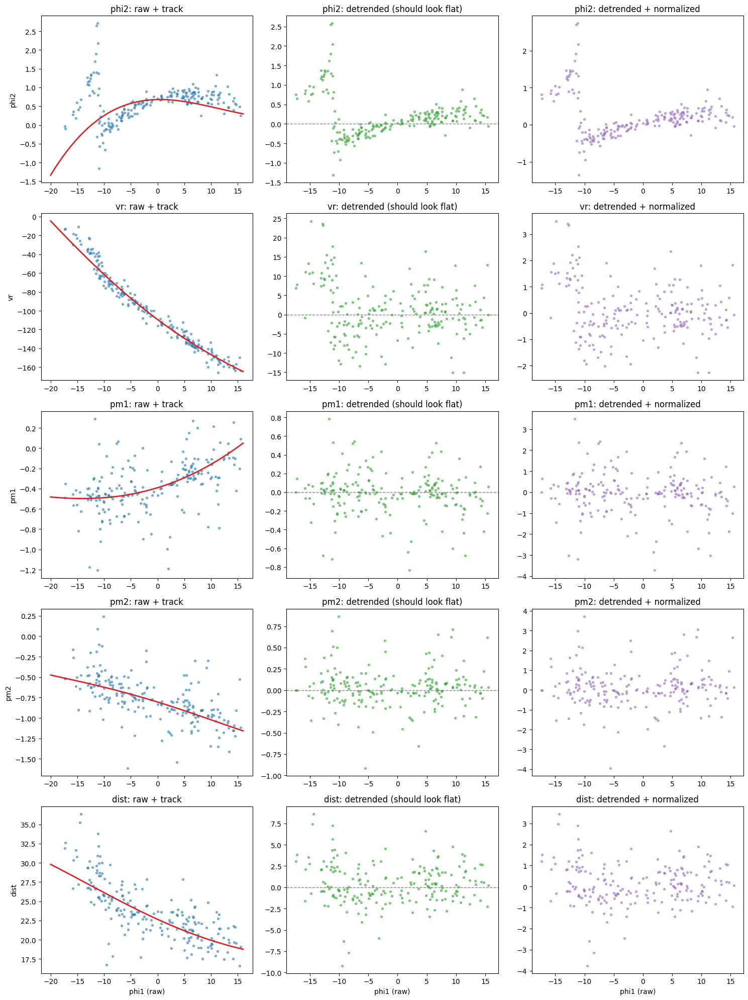

feature     raw std   detrended std   normalized mean   normalized std
phi2         0.4812          0.5441            0.2060           0.5725
vr          40.2902          6.9761            0.0947           1.0202
pm1          0.2554          0.2266           -0.0594           1.0094
pm2          0.2823          0.2274            0.1152           0.9792
dist         3.7476          2.4078            0.1115           0.9756


In [24]:
import copy
import matplotlib.pyplot as plt

feature_names = ['phi1', 'phi2', 'vr', 'pm1', 'pm2', 'dist']
phi1_idx = feature_names.index("phi1")

# work on a fresh copy so we don't clobber the graph you'll actually run inference on
#graph_raw = copy.deepcopy(data[i])

# AFTER
N_SUBSAMPLE = 200
rng = np.random.default_rng(seed=42)          # same seed as inference cell → same particles

graph_raw_full = copy.deepcopy(data_nbody[i])
idx_sub = rng.choice(graph_raw_full.x.shape[0], size=N_SUBSAMPLE, replace=False)
idx_sub_t = torch.from_numpy(idx_sub)

graph_raw = copy.deepcopy(graph_raw_full)
graph_raw.x   = graph_raw.x[idx_sub_t]
graph_raw.pos = graph_raw.pos[idx_sub_t]

graph_detrended = copy.deepcopy(graph_raw)

# apply detrending only (no normalization yet), so we can compare raw vs detrended
graph_detrended = particle_dataset._subtract_track_from_data(
    [graph_detrended], feature_names, track_feature=None, track_path=track_paths
)[0]

# apply normalization on top of the detrended version (this matches your actual pipeline)
graph_normalized = copy.deepcopy(graph_detrended)
graph_normalized.x = (graph_normalized.x - x_loc) / x_scale

phi1_vals = graph_raw.x[:, phi1_idx].numpy()

features_to_plot = ['phi2', 'vr', 'pm1', 'pm2', 'dist']

fig, axes = plt.subplots(len(features_to_plot), 3, figsize=(15, 4 * len(features_to_plot)))

for row, feat in enumerate(features_to_plot):
    feat_idx = feature_names.index(feat)

    raw_vals = graph_raw.x[:, feat_idx].numpy()
    detrended_vals = graph_detrended.x[:, feat_idx].numpy()
    normalized_vals = graph_normalized.x[:, feat_idx].numpy()

    # overlay the fitted track on the raw panel
    track, info = particle_dataset._load_track_poly(track_paths[feat])
    phi1_fine = np.linspace(info["phi1_min"], info["phi1_max"], 200)
    track_curve = track(phi1_fine)

    axes[row, 0].scatter(phi1_vals, raw_vals, s=8, alpha=0.5)
    axes[row, 0].plot(phi1_fine, track_curve, color="tab:red", lw=2)
    axes[row, 0].set_title(f"{feat}: raw + track")
    axes[row, 0].set_ylabel(feat)

    axes[row, 1].scatter(phi1_vals, detrended_vals, s=8, alpha=0.5, color="tab:green")
    axes[row, 1].axhline(0, color="gray", lw=1, ls="--")
    axes[row, 1].set_title(f"{feat}: detrended (should look flat)")

    axes[row, 2].scatter(phi1_vals, normalized_vals, s=8, alpha=0.5, color="tab:purple")
    axes[row, 2].set_title(f"{feat}: detrended + normalized")

for ax in axes[-1, :]:
    ax.set_xlabel("phi1 (raw)")

plt.tight_layout()
plt.show()

# quick numeric summary
print(f"{'feature':<8} {'raw std':>10} {'detrended std':>15} {'normalized mean':>17} {'normalized std':>16}")
for feat in features_to_plot:
    feat_idx = feature_names.index(feat)
    raw_std = graph_raw.x[:, feat_idx].std().item()
    detrended_std = graph_detrended.x[:, feat_idx].std().item()
    norm_mean = graph_normalized.x[:, feat_idx].mean().item()
    norm_std = graph_normalized.x[:, feat_idx].std().item()
    print(f"{feat:<8} {raw_std:>10.4f} {detrended_std:>15.4f} {norm_mean:>17.4f} {norm_std:>16.4f}")

In [25]:
# Inference
all_posteriors = model.sample_from_loader(graph_loader, num_samples=100000)

# convert posterior back to physical units
y_loc = torch.tensor(norm_dict.y_loc, dtype=torch.float32)
y_scale = torch.tensor(norm_dict.y_scale, dtype=torch.float32)
all_posteriors = all_posteriors * y_scale + y_loc

all_posteriors = all_posteriors.cpu().numpy()  # move to CPU and convert to numpy array

100%|██████████| 1/1 [00:03<00:00,  3.46s/it]


In [26]:
# posterior = all_posteriors[0]
# fig = corner.corner(
#     posterior,
#     truths=true_params_dict.values(),
#     labels=labels,
#     show_titles=True,
#     title_fmt=".2f",
# )

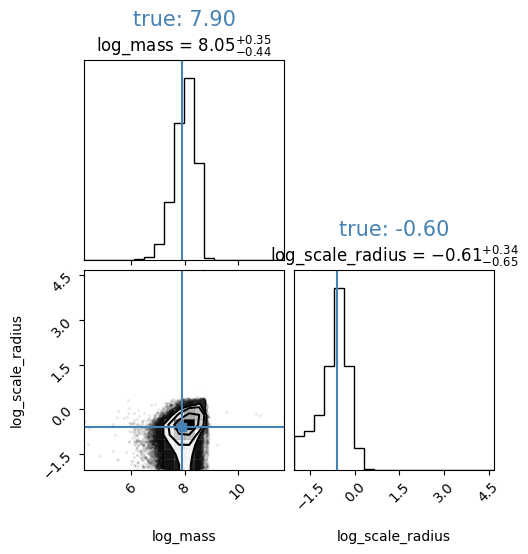

In [27]:
plt.close('all')  # clear any stale figure state

# indices for the params you care about
idx = [labels.index('log_mass'), labels.index('log_scale_radius')]

posterior_sub = all_posteriors[0][:, idx]          # (num_samples, 2)
truths_sub = [true_params_dict['log_mass'], true_params_dict['log_scale_radius']]
labels_sub = ['log_mass', 'log_scale_radius']

fig = corner.corner(
    posterior_sub,
    truths=truths_sub,
    labels=labels_sub,
    show_titles=True,
    title_fmt=".2f",
    #range = [0.999, 0.999],
)

# diagonal axes for a 2-param corner plot are at positions 0 and 3
n_params = len(labels_sub)
diag_axes = [fig.axes[i * n_params + i] for i in range(n_params)]

truth_color = "#4682b4"
for ax, true_val, label in zip(diag_axes, truths_sub, labels_sub):
    ax.text(
        0.5, 1.15,                      # x, y in axes-fraction coords (above existing title)
        f"true: {true_val:.2f}",
        color=truth_color,
        ha='center', va='bottom',
        transform=ax.transAxes,
        fontsize=15,
    )

In [28]:
def plot_pretty(dpi=175, fontsize=15, labelsize=15, figsize=(10, 8), tex=True):
    # import pyplot and set some parameters to make plots prettier

    plt.rc('savefig', dpi=dpi)
    plt.rc('text', usetex=tex)
    plt.rc('font', size=fontsize)
    plt.rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
    plt.rc('xtick.major', pad=5)
    plt.rc('xtick.minor', pad=5)
    plt.rc('ytick.major', pad=5)
    plt.rc('ytick.minor', pad=5)
    plt.rc('figure', figsize=figsize)

    mpl.rcParams['xtick.labelsize'] = labelsize
    mpl.rcParams['ytick.labelsize'] = labelsize
    mpl.rcParams.update({'figure.autolayout': True})

from mpl_toolkits.axes_grid1.axes_divider import make_axes_locatable

def colorbar(mappable):
    ax = mappable.axes
    fig = ax.figure
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    return fig.colorbar(mappable, cax=cax)

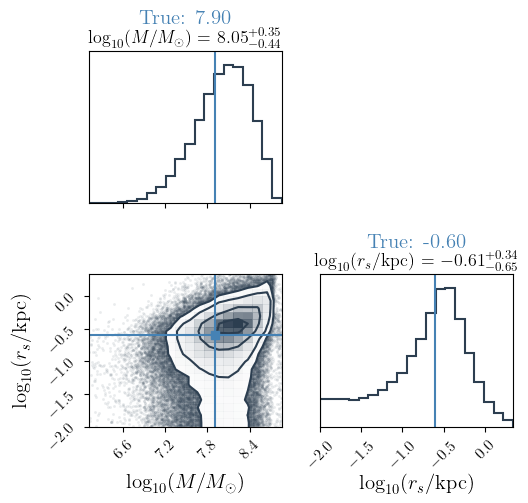

In [29]:
plot_pretty(dpi=175, fontsize=15, labelsize=13, figsize=(8, 8), tex=True)

plt.close('all')  # clear any stale figure state

# indices for the params you care about
idx = [labels.index('log_mass'), labels.index('log_scale_radius')]
posterior_sub = all_posteriors[0][:, idx]          # (num_samples, 2)
truths_sub = [true_params_dict['log_mass'], true_params_dict['log_scale_radius']]
#labels_sub = ['log_mass', 'log_scale_radius']
labels_sub = [
    r'$\log_{10}(M/M_\odot)$',
    r'$\log_{10}(r_s/\mathrm{kpc})$'
]

fig = corner.corner(
    posterior_sub,
    truths=truths_sub,
    labels=labels_sub,
    show_titles=True,
    title_fmt=".2f",
    truth_color="#4682b4",
    color="#2c3e50",
    hist_kwargs={"color": "#2c3e50", "linewidth": 1.5},
    label_kwargs={"fontsize": 15},
    title_kwargs={"fontsize": 13},
    range = [0.999, 0.999],
)

# diagonal axes for a 2-param corner plot are at positions 0 and 3
n_params = len(labels_sub)
diag_axes = [fig.axes[i * n_params + i] for i in range(n_params)]
truth_color = "#4682b4"
for ax, true_val, label in zip(diag_axes, truths_sub, labels_sub):
    ax.text(
        0.5, 1.15,
        f"True: {true_val:.2f}",
        color=truth_color,
        ha='center', va='bottom',
        transform=ax.transAxes,
        fontsize=15,
    )

# tidy up tick label sizes on all axes (corner sets its own by default)
for ax in fig.axes:
    ax.tick_params(labelsize=11)

#fig.suptitle("AAU Subhalo Posterior: log_mass vs log_scale_radius", y=1.05, fontsize=15)

#plt.savefig("corner_log_mass_log_scale_radius.pdf", bbox_inches="tight")
plt.show()

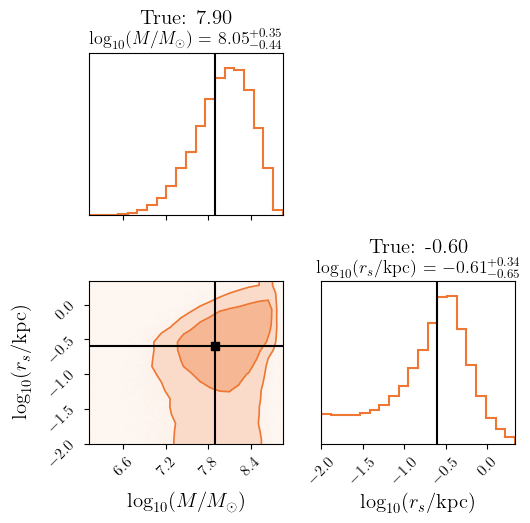

In [30]:
import matplotlib.colors as mcolors

plot_pretty(dpi=175, fontsize=15, labelsize=13, figsize=(8, 8), tex=True)
plt.close('all')

idx = [labels.index('log_mass'), labels.index('log_scale_radius')]
posterior_sub = all_posteriors[0][:, idx]
truths_sub = [true_params_dict['log_mass'], true_params_dict['log_scale_radius']]
labels_sub = [
    r'$\log_{10}(M/M_\odot)$',
    r'$\log_{10}(r_s/\mathrm{kpc})$'
]
''
steel = mcolors.to_rgb(color_nbody)
cmap_sb = mcolors.LinearSegmentedColormap.from_list(
    'white_to_steelblue',
    [(0,   (1, 1, 1)),
     (0.4, (*steel, 0.35)),
     (1.0, (*steel, 0.85)),
    ]
)

fig = corner.corner(
    posterior_sub,
    truths=truths_sub,
    labels=labels_sub,
    show_titles=True,
    title_fmt=".2f",
    truth_color='black',
    color=color_nbody,
    fill_contours=True,
    levels=[0.68, 0.95],
    hist_kwargs={"color": color_nbody, "linewidth": 1.5},
    contour_kwargs={"colors": [color_nbody], "linewidths": 1.2},
    contourf_kwargs={"cmap": cmap_sb, "colors": None},
    label_kwargs={"fontsize": 15},
    title_kwargs={"fontsize": 13},
    range=[0.999, 0.999],
)

n_params = len(labels_sub)
diag_axes = [fig.axes[i * n_params + i] for i in range(n_params)]
for ax, true_val in zip(diag_axes, truths_sub):
    ax.text(
        0.5, 1.15, f"True: {true_val:.2f}",
        color='black',
        ha='center', va='bottom',
        transform=ax.transAxes,
        fontsize=15,
    )

for ax in fig.axes:
    ax.tick_params(labelsize=11)


plt.savefig("corner_log_mass_log_scale_radius_nbody_small.png", dpi = 300,bbox_inches="tight")
plt.show()


In [31]:
plt.close('all')  # clear any stale figure state

labels_sub = ['log_mass', 'log_scale_radius', 'phi1_impact_today', 'time_impact',
          'impact_parameter', 'v_rel_para', 'v_rel_perp',
          'angle_pos_at_impact', 'delta_angle']

idx = list(range(len(labels_sub)))

posterior_sub = all_posteriors[0][:, idx]
truths_sub = [true_params_dict[l] for l in labels_sub]

print(f"{'label':<25} {'std':>10} {'min':>10} {'max':>10} {'true':>10}")
for row_i, l in enumerate(labels_sub):
    std = posterior_sub[:, row_i].std()
    lo, hi = posterior_sub[:, row_i].min(), posterior_sub[:, row_i].max()
    true_val = true_params_dict.get(l, float('nan'))
    print(f"{l:<25} {std:>10.4f} {lo:>10.4f} {hi:>10.4f} {true_val:>10.4f}")

label                            std        min        max       true
log_mass                      0.3983     4.2166    11.7493     7.9031
log_scale_radius              0.5003    -2.0372     4.6844    -0.6021
phi1_impact_today             1.7637   -19.5398    -7.8899   -12.5000
time_impact                   0.0705    -0.6038     0.3909    -0.2500
impact_parameter              0.8641     0.0505     5.8161     0.5000
v_rel_para                   52.8999  -894.8916   884.2684   -10.0000
v_rel_perp                   36.7867  -282.7328   558.7007    65.0000
angle_pos_at_impact          51.1163    -3.3046   402.4968     5.0000
delta_angle                  37.1584  -384.4116   285.4011     5.0000


In [32]:
# plt.close('all')

# fig = corner.corner(
#     posterior_sub,
#     truths=truths_sub,
#     labels=labels_sub,
#     show_titles=True,
#     title_fmt=".2f",
#     fig=plt.figure(figsize=(22, 22)),
#     #range = [0.9999, 0.9999, 0.9999, 0.9999, 0.9999, 0.9999, 0.9999, 0.9999, 0.9999],
# )

# n_params = len(labels_sub)
# diag_axes = [fig.axes[i * n_params + i] for i in range(n_params)]

# truth_color = "#4682b4"
# for ax, true_val, label in zip(diag_axes, truths_sub, labels_sub):
#     ax.text(
#         0.5, 1.15,
#         f"true: {true_val:.2f}",
#         color=truth_color,
#         ha='center', va='bottom',
#         transform=ax.transAxes,
#         fontsize=13,
#     )

# plt.tight_layout()
# plt.show()

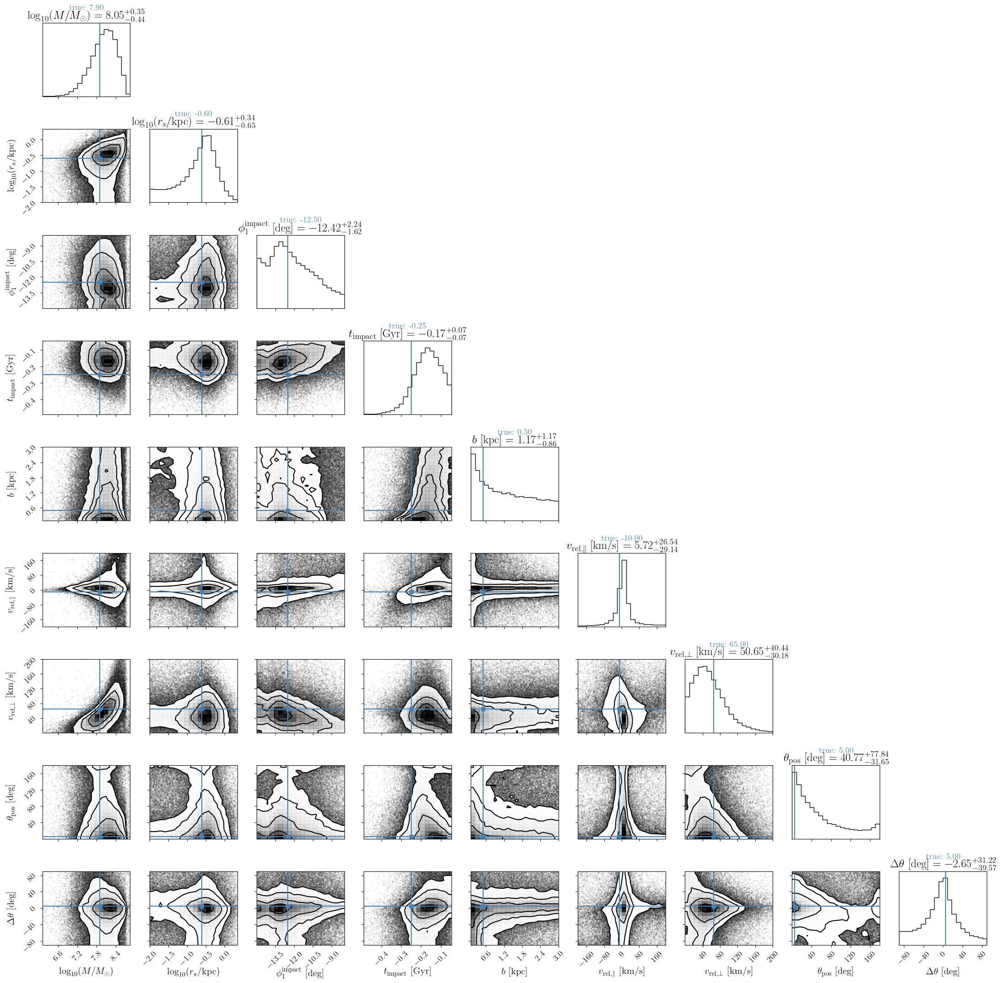

In [33]:
plt.close('all')

# label -> (display name with units, explicit (min, max) range or None for auto)
label_info = {
    'log_mass':             (r'$\log_{10}(M/M_\odot)$', None),
    'log_scale_radius':     (r'$\log_{10}(r_s / \mathrm{kpc})$', None),
    'phi1_impact_today':    (r'$\phi_1^{\rm impact}$ [deg]', (-15, -8)),
    'time_impact':          (r'$t_{\rm impact}$ [Gyr]', None),
    'impact_parameter':     (r'$b$ [kpc]', None),
    'v_rel_para':           (r'$v_{\rm rel,\parallel}$ [km/s]', (-200, 200)),
    'v_rel_perp':           (r'$v_{\rm rel,\perp}$ [km/s]', (0, 200)),
    'angle_pos_at_impact':  (r'$\theta_{\rm pos}$ [deg]', (0, 180)),
    'delta_angle':          (r'$\Delta\theta$ [deg]', (-90, 90)),
}

labels_display = [label_info[l][0] for l in labels_sub]
plot_range = [label_info[l][1] if label_info[l][1] is not None else 0.999 for l in labels_sub]

fig = corner.corner(
    posterior_sub,
    truths=truths_sub,
    labels=labels_display,
    show_titles=True,
    title_fmt=".2f",
    fig=plt.figure(figsize=(22, 22)),
    range=plot_range,
)

n_params = len(labels_sub)
diag_axes = [fig.axes[i * n_params + i] for i in range(n_params)]

truth_color = "#4682b4"
for ax, true_val, label in zip(diag_axes, truths_sub, labels_sub):
    ax.text(
        0.5, 1.15,
        f"true: {true_val:.2f}",
        color=truth_color,
        ha='center', va='bottom',
        transform=ax.transAxes,
        fontsize=13,
    )

plt.tight_layout()
plt.show()

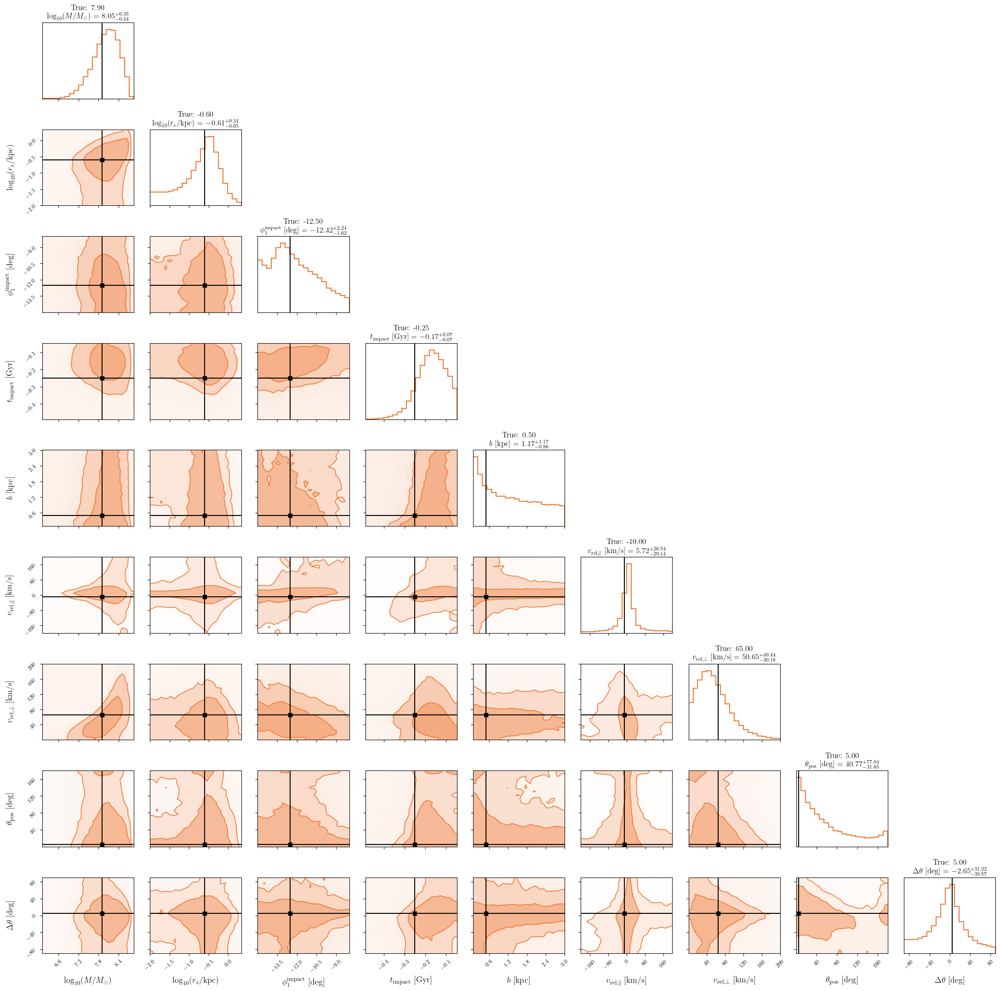

In [34]:
import matplotlib.colors as mcolors

plot_pretty(dpi=175, fontsize=13, labelsize=11, figsize=(8, 8), tex=True)
plt.close('all')

steel = mcolors.to_rgb(color_nbody)
cmap_sb = mcolors.LinearSegmentedColormap.from_list(
    'white_to_steelblue',
    [(0,   (1, 1, 1)),
     (0.4, (*steel, 0.35)),
     (1.0, (*steel, 0.85)),
    ]
)

label_info = {
    'log_mass':             (r'$\log_{10}(M/M_\odot)$',            None),
    'log_scale_radius':     (r'$\log_{10}(r_s / \mathrm{kpc})$',   None),
    'phi1_impact_today':    (r'$\phi_1^{\rm impact}$ [deg]',        (-15, -8)),
    'time_impact':          (r'$t_{\rm impact}$ [Gyr]',             None),
    'impact_parameter':     (r'$b$ [kpc]',                          None),
    'v_rel_para':           (r'$v_{\rm rel,\parallel}$ [km/s]',     (-200, 200)),
    'v_rel_perp':           (r'$v_{\rm rel,\perp}$ [km/s]',         (0, 200)),
    'angle_pos_at_impact':  (r'$\theta_{\rm pos}$ [deg]',           (0, 180)),
    'delta_angle':          (r'$\Delta\theta$ [deg]',               (-90, 90)),
}

labels_display = [label_info[l][0] for l in labels_sub]
plot_range     = [label_info[l][1] if label_info[l][1] is not None else 0.999 for l in labels_sub]

fig = corner.corner(
    posterior_sub,
    truths=truths_sub,
    labels=labels_display,
    show_titles=True,
    title_fmt=".2f",
    fig=plt.figure(figsize=(22, 22)),
    truth_color='black',
    color=color_nbody,
    fill_contours=True,
    levels=[0.68, 0.95],
    hist_kwargs={"color": color_nbody, "linewidth": 1.5},
    contour_kwargs={"colors": [color_nbody], "linewidths": 1.2},
    contourf_kwargs={"cmap": cmap_sb, "colors": None},
    label_kwargs={"fontsize": 13},
    title_kwargs={"fontsize": 12},
    range=plot_range,
)

n_params = len(labels_sub)
diag_axes = [fig.axes[i * n_params + i] for i in range(n_params)]
for ax, true_val, label in zip(diag_axes, truths_sub, labels_sub):
    ax.text(
        0.5, 1.15, f"True: {true_val:.2f}",
        color='black',
        ha='center', va='bottom',
        transform=ax.transAxes,
        fontsize=12,
    )

for ax in fig.axes:
    ax.tick_params(labelsize=9)

plt.tight_layout()

plt.savefig("corner_log_mass_log_scale_radius_nbody.png", dpi = 300,bbox_inches="tight")
plt.savefig("corner_log_mass_log_scale_radius_nbody.pdf", dpi = 300,bbox_inches="tight")
plt.show()

In [35]:
np.savez(
    "corner_cache_nbody.npz",
    posterior = posterior_sub,
    truths    = np.array(truths_sub),
    labels    = np.array(labels_sub),
)
print("Saved corner_cache_nbody.npz")

Saved corner_cache_nbody.npz


In [36]:
all_posteriors_flat = all_posteriors.squeeze(0)  # (num_samples, output_size)

In [37]:
model.eval()
with torch.no_grad():
    # Replicate sample_from_batch to get the embedding
    batch = next(iter(graph_loader))
    if model.pre_transforms is not None:
        batch = model.pre_transforms(batch)
    batch_dict = model.embedding_nn._prepare_batch(batch)
    embedding = model.embedding_nn(batch_dict)  # (1, embedding_dim)

    # Normalize posterior samples back to model's internal space
    posterior_tensor = torch.tensor(all_posteriors, dtype=torch.float32).to(embedding.device)
    posterior_normalized = (posterior_tensor - y_loc.to(embedding.device)) / y_scale.to(embedding.device)

    # Score in chunks to avoid OOM
    posterior_normalized_flat = posterior_normalized.squeeze(0)  # (100000, 9)

    chunk_size = 10000
    log_probs_list = []
    for i in range(0, len(posterior_normalized_flat), chunk_size):
        chunk = posterior_normalized_flat[i:i + chunk_size]
        emb_expanded = embedding.expand(len(chunk), -1)
        lp = model.log_prob(emb_expanded, chunk)
        log_probs_list.append(lp.cpu())
        
log_probs_np = torch.cat(log_probs_list).numpy()

top10_idx = np.argsort(log_probs_np)[::-1][:10]

print("Top 10 highest-probability samples:")
print(f"{'Rank':<6}", " ".join(f"{l:>22}" for l in labels_sub))
print("-" * (6 + 23 * len(labels_sub)))

for rank, idx in enumerate(top10_idx):
    vals = all_posteriors_flat[idx].flatten()
    print(f"{rank+1:<6}", " ".join(f"{v:>22.4f}" for v in vals))

best = all_posteriors_flat[top10_idx[0]].flatten()
best_dict = dict(zip(labels_sub, best))
print("\nMAP estimate:")
for k, v in best_dict.items():
    print(f"  {k}: {v:.4f}")

Top 10 highest-probability samples:
Rank                 log_mass       log_scale_radius      phi1_impact_today            time_impact       impact_parameter             v_rel_para             v_rel_perp    angle_pos_at_impact            delta_angle
---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
1                      8.0939                -0.4591               -12.9881                -0.2000                 0.6519                -1.4103                62.1416                46.0504               -11.5047
2                      7.9173                -0.4636               -13.2642                -0.1903                 0.3023                 5.3841                48.3008                23.3611                -2.8969
3                      7.9440                -0.3733               -13.4515                -0.2376          

### Make PS Stream From MAP

In [38]:
import sys
import pickle
import numpy as np

sys.path.append("/global/homes/e/emarin4/scratch/training_sims/aau_sbi_fastsims/workspace/scripts")

import sims_funcs_refined as sfr

sys.path.append("/global/homes/e/emarin4/scratch/training_sims")

import Nbody_streams.nbody_streams as nbody
import agama
agama.setUnits(mass=1, length=1, velocity=1)

In [39]:
BASE_PATH = "/global/homes/e/emarin4/scratch/training_sims/aau_sbi_fastsims/scripts"

potMW  = agama.Potential(file=f"{BASE_PATH}/McMillan17_nora.ini")
accMW  = np.loadtxt(f"{BASE_PATH}/accMW")
trajLMC = np.loadtxt(f"{BASE_PATH}/trajLMC")

potacc  = agama.Potential(type='UniformAcceleration', file=accMW)
potLMC  = agama.Potential(file=f"{BASE_PATH}/LMC_nora.ini")
potLMCm = agama.Potential(potential=potLMC, center=trajLMC)

potTotal = agama.Potential(potMW, potLMCm, potacc)

In [40]:
with open("/global/homes/e/emarin4/scratch/training_sims/aau_sbi_fastsims/workspace/stream_unperturbed_810.pkl", "rb") as f:
    streamdata = pickle.load(f)
meta = streamdata["metadata"]

distrib_stripping = np.load("/global/homes/e/emarin4/scratch/training_sims/Nbody_streams/examples/output/host_potential/gauss_stripping_810.npy")

In [41]:
# Fill peak from MAP estimate
peak = {
    "log_mass":            best_dict["log_mass"],
    "log_scale_radius":    best_dict["log_scale_radius"],
    "phi1_impact_today":   best_dict["phi1_impact_today"],
    "time_impact":         best_dict["time_impact"],
    "impact_parameter":    best_dict["impact_parameter"],
    "v_rel_para":          best_dict["v_rel_para"],
    "v_rel_perp":          best_dict["v_rel_perp"],
    "angle_pos_at_impact": best_dict["angle_pos_at_impact"],
    "delta_angle":         best_dict["delta_angle"],
}

print("MAP peak values:")
for k, v in peak.items():
    print(f"  {k}: {v:.4f}")



MAP peak values:
  log_mass: 8.0939
  log_scale_radius: -0.4591
  phi1_impact_today: -12.9881
  time_impact: -0.2000
  impact_parameter: 0.6519
  v_rel_para: -1.4103
  v_rel_perp: 62.1416
  angle_pos_at_impact: 46.0504
  delta_angle: -11.5047


In [42]:
# Build pert_dict properly using sfr.create_perturber_dict

# Get the unperturbed stream particles in Cartesian coords and phi1
stream_cart  = streamdata["stream"]["part_xv"]      # (N, 6) Galactocentric Cartesian
stream_phi1  = streamdata["phi1"]           # (N,) phi1 coords of unperturbed stream

pert_dict = sfr.create_perturber_dict(
    stream_today_cart        = stream_cart,
    stream_today_phi1        = stream_phi1,
    potential                = potTotal,
    mass_perturber           = 10 ** best_dict["log_mass"],
    scaleradius_perturber    = 10 ** best_dict["log_scale_radius"],
    impact_phi1              = best_dict["phi1_impact_today"],
    impact_time              = float(best_dict["time_impact"]),
    impact_parameter         = best_dict["impact_parameter"],
    v_rel_parallel           = best_dict["v_rel_para"],
    v_rel_perpendicular      = best_dict["v_rel_perp"],
    alpha_position           = best_dict["angle_pos_at_impact"],
    alpha_velocity           = best_dict["angle_pos_at_impact"] + best_dict["delta_angle"],
    time_window              = sfr.compute_time_window(best_dict["v_rel_perp"], best_dict["v_rel_para"],
                                                        best_dict["impact_parameter"])
)

print("Perturber dict:")
for k, v in pert_dict.items():
    if hasattr(v, '__len__'):
        print(f"  {k}: {v}")
    else:
        print(f"  {k}: {v:.4f}")

Perturber dict:
  mass: 124135475.5096
  scaleRadius: 0.3475
  w_subhalo_impact: [-12.66571064 -31.95719311 -22.00700161  -0.1224071   97.84119271
 -79.73767367]
  time_impact: -0.2000
  time_window: 1.4158


In [43]:
def simulate_stream_from_pert(pert_dict, meta, distrib_stripping):
    stream_perturb = nbody.fast_sims.create_particle_spray_stream(
        pot_host=potTotal,
        initmass=meta["prog_mass_Msun"],
        scaleradius=meta["prog_scaleradius_kpc"],
        prog_pot_kind='Plummer',
        sat_cen_present=meta["prog_wtoday"],
        num_particles=meta["num_particles"],
        time_end=0.0,
        time_total=meta["Age_stream_Gyr"],
        save_rate=1,
        time_stripping=distrib_stripping,
        add_perturber=pert_dict,
        verbose=False,
        dissolve_progenitor=True,
        seed=None,
    )
    part_xv = stream_perturb["part_xv"]
    coords  = sfr.galcen_to_aau_full(part_xv)
    feature_names = ['phi1', 'phi2', 'vr', 'pm1', 'pm2', 'dist']
    feats   = np.column_stack([coords[name] for name in feature_names])
    return feats, part_xv

feats, part_xv = simulate_stream_from_pert(pert_dict, meta, distrib_stripping)
print(f"Simulated stream: {feats.shape[0]} particles, {feats.shape[1]} features")

Simulated stream: 200 particles, 6 features


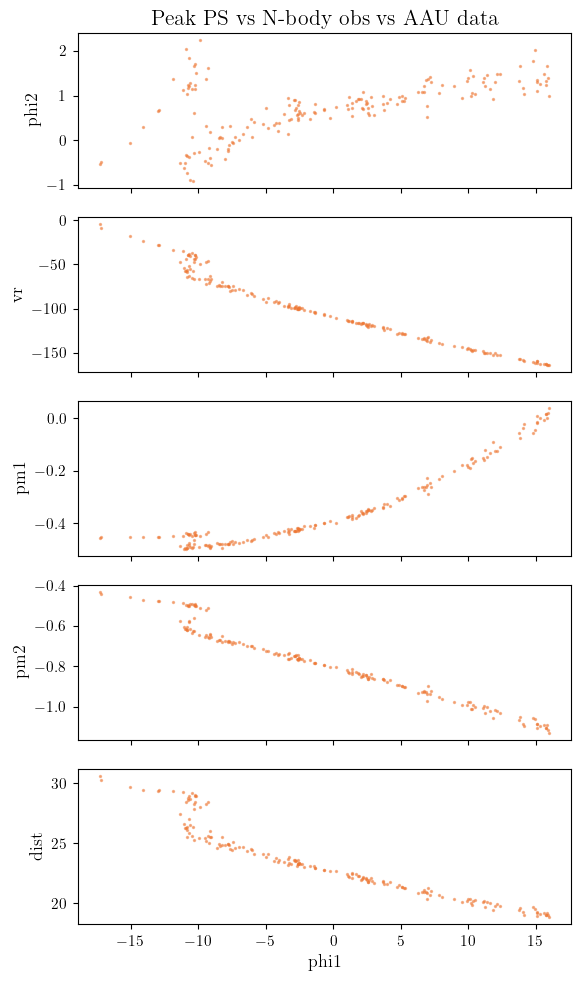

In [44]:
features = ['phi1', 'phi2', 'vr', 'pm1', 'pm2', 'dist']

phi1_ps_peak = feats[:, 0]
mask = (phi1_ps_peak >= -20) & (phi1_ps_peak < 16)
feats_cut = feats[mask]
phi1_cut  = feats_cut[:, 0]

fig, axes = plt.subplots(5, figsize=(6, 10), sharex=True)
for j, ax in enumerate(axes):
    #ax.scatter(phi1_nbody,        stream_nbody[:, 1 + j], s=0.5, c='k',         alpha=0.5, label='N-body (obs)')
    ax.scatter(phi1_cut,          feats_cut[:, 1 + j],    s=2, c=color_nbody, alpha=0.5, label='PS (peak)')
    # ax.scatter(aau_cut['phi1'],   aau_cut[list(aau_cols.values())[j]].values, 
    #            s=2, c='crimson', alpha=0.9, label='AAU data', zorder=5)
    ax.set_ylabel(features[j + 1])

#axes[0].legend(markerscale=2, loc='upper right')
axes[-1].set_xlabel('phi1')
axes[0].set_title('Peak PS vs N-body obs vs AAU data')
plt.tight_layout()
plt.show()

In [45]:
# ── Cell: simulate top 10 MAP streams ────────────────────────────────────────
top10_feats = []

for rank, idx in enumerate(top10_idx):
    params = dict(zip(labels_sub, all_posteriors_flat[idx].flatten()))
    print(f"Simulating rank {rank + 1} / 10 ...")

    pert = sfr.create_perturber_dict(
        stream_today_cart        = stream_cart,
        stream_today_phi1        = stream_phi1,
        potential                = potTotal,
        mass_perturber           = 10 ** params["log_mass"],
        scaleradius_perturber    = 10 ** params["log_scale_radius"],
        impact_phi1              = params["phi1_impact_today"],
        impact_time              = float(params["time_impact"]),
        impact_parameter         = params["impact_parameter"],
        v_rel_parallel           = params["v_rel_para"],
        v_rel_perpendicular      = params["v_rel_perp"],
        alpha_position           = params["angle_pos_at_impact"],
        alpha_velocity           = params["angle_pos_at_impact"] + params["delta_angle"],
        time_window              = sfr.compute_time_window(
                                       params["v_rel_perp"], params["v_rel_para"],
                                       params["impact_parameter"])
    )

    feats_i, _ = simulate_stream_from_pert(pert, meta, distrib_stripping)
    top10_feats.append(feats_i)

print("Done.")

Simulating rank 1 / 10 ...
Simulating rank 2 / 10 ...
Simulating rank 3 / 10 ...
Simulating rank 4 / 10 ...
Simulating rank 5 / 10 ...
Simulating rank 6 / 10 ...
Simulating rank 7 / 10 ...
Simulating rank 8 / 10 ...
Simulating rank 9 / 10 ...
Simulating rank 10 / 10 ...
Done.


/tmp/ipykernel_1462511/1379358626.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = get_cmap('Blues')


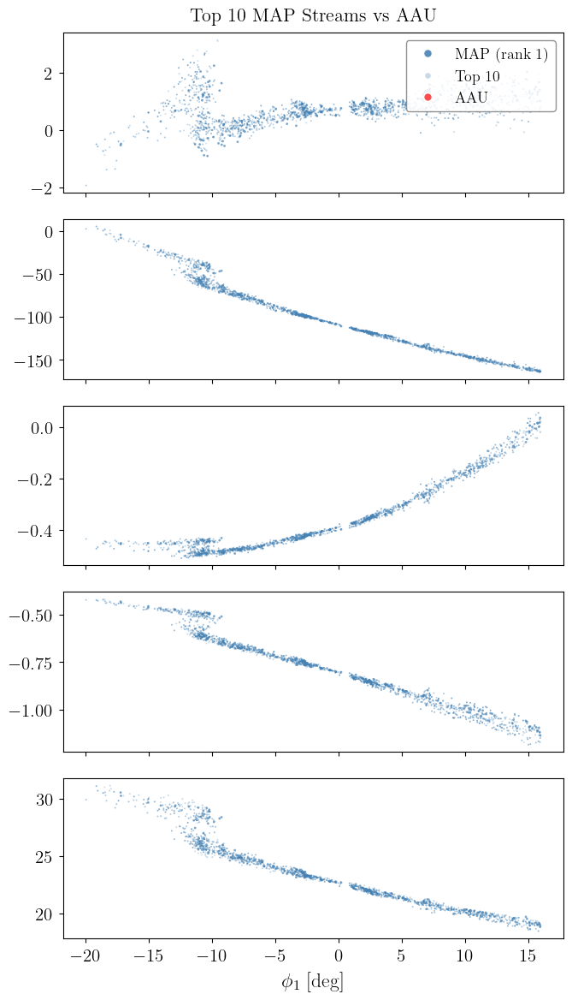

In [46]:
# ── Cell: plot top 10 MAP streams ────────────────────────────────────────────
plot_pretty(dpi=175, fontsize=17, labelsize=15, figsize=(8, 10), tex=True)

greek_labels = {
    'phi2': r'$\phi_2$ [deg]',
    'vr':   r'$v_r$ [km/s]',
    'pm1':  r'$\mu_{\phi_1}$ [mas/yr]',
    'pm2':  r'$\mu_{\phi_2}$ [mas/yr]',
    'dist': r'$d$ [kpc]',
}

from matplotlib.lines import Line2D
from matplotlib.cm import get_cmap
cmap   = get_cmap('Blues')
alphas = np.linspace(0.25, 0.7, 10)   # rank 1 gets highest alpha

fig, axes = plt.subplots(5, 1, figsize=(7, 12), sharex=True)
fig.subplots_adjust(hspace=0.08)

for rank, feats_i in enumerate(top10_feats):
    phi1_i = feats_i[:, 0]
    mask_i = (phi1_i >= phi1_min) & (phi1_i < phi1_max)
    feats_cut_i = feats_i[mask_i]
    phi1_cut_i  = feats_cut_i[:, 0]
    alpha = alphas[-(rank + 1)]          # rank 0 (MAP) is most opaque
    size  = 4 if rank == 0 else 2

    for j, ax in enumerate(axes):
        ax.scatter(
            phi1_cut_i, feats_cut_i[:, j + 1],
            s=size, c='steelblue', alpha=alpha,
            edgecolors='none', rasterized=True,
            label='MAP' if (rank == 0 and j == 0) else None,
        )

# AAU overlay
# for j, ax in enumerate(axes):
#     feat = list(greek_labels.keys())[j]
#     ax.scatter(
#         aau_cut['phi1'].values, aau_cols[feat],
#         s=9, c='#FF4C4C', alpha=1.0, zorder=5,
#         edgecolors='none',
#         label='AAU' if j == 0 else None,
#     )
#     ax.set_ylabel(greek_labels[feat], labelpad=6)
#     ax.yaxis.set_minor_locator(plt.AutoLocator())
#     ax.tick_params(which='both', direction='in', top=True, right=True)

# Legend: MAP rank 1 + top 10 faded + AAU
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='steelblue',
           markersize=7, alpha=0.9, label='MAP (rank 1)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='steelblue',
           markersize=5, alpha=0.3, label='Top 10'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#FF4C4C',
           markersize=7, label='AAU'),
]
axes[0].legend(handles=legend_elements, loc='upper right',
               framealpha=0.85, edgecolor='gray', fontsize=13)
axes[-1].set_xlabel(r'$\phi_1$ [deg]', labelpad=6)
axes[0].set_title('Top 10 MAP Streams vs AAU', fontsize=16, pad=10)

plt.tight_layout()
plt.show()

In [47]:
top100_idx = np.argsort(log_probs_np)[::-1][:100]
top1000_idx = np.argsort(log_probs_np)[::-1][:1000]

In [48]:
top100_feats = []
top1000_feats = []

for rank, idx in enumerate(top100_idx):
    params = dict(zip(labels_sub, all_posteriors_flat[idx].flatten()))
    print(f"Simulating rank {rank + 1} / 100 ...")

    pert = sfr.create_perturber_dict(
        stream_today_cart        = stream_cart,
        stream_today_phi1        = stream_phi1,
        potential                = potTotal,
        mass_perturber           = 10 ** params["log_mass"],
        scaleradius_perturber    = 10 ** params["log_scale_radius"],
        impact_phi1              = params["phi1_impact_today"],
        impact_time              = float(params["time_impact"]),
        impact_parameter         = params["impact_parameter"],
        v_rel_parallel           = params["v_rel_para"],
        v_rel_perpendicular      = params["v_rel_perp"],
        alpha_position           = params["angle_pos_at_impact"],
        alpha_velocity           = params["angle_pos_at_impact"] + params["delta_angle"],
        time_window              = sfr.compute_time_window(
                                       params["v_rel_perp"], params["v_rel_para"],
                                       params["impact_parameter"])
    )

    feats_i, _ = simulate_stream_from_pert(pert, meta, distrib_stripping)
    top100_feats.append(feats_i)

print("Done.")

Simulating rank 1 / 100 ...
Simulating rank 2 / 100 ...
Simulating rank 3 / 100 ...
Simulating rank 4 / 100 ...
Simulating rank 5 / 100 ...
Simulating rank 6 / 100 ...
Simulating rank 7 / 100 ...
Simulating rank 8 / 100 ...
Simulating rank 9 / 100 ...
Simulating rank 10 / 100 ...
Simulating rank 11 / 100 ...
Simulating rank 12 / 100 ...
Simulating rank 13 / 100 ...
Simulating rank 14 / 100 ...
Simulating rank 15 / 100 ...
Simulating rank 16 / 100 ...
Simulating rank 17 / 100 ...
Simulating rank 18 / 100 ...
Simulating rank 19 / 100 ...
Simulating rank 20 / 100 ...
Simulating rank 21 / 100 ...
Simulating rank 22 / 100 ...
Simulating rank 23 / 100 ...
Simulating rank 24 / 100 ...
Simulating rank 25 / 100 ...
Simulating rank 26 / 100 ...
Simulating rank 27 / 100 ...
Simulating rank 28 / 100 ...
Simulating rank 29 / 100 ...
Simulating rank 30 / 100 ...
Simulating rank 31 / 100 ...
Simulating rank 32 / 100 ...
Simulating rank 33 / 100 ...
Simulating rank 34 / 100 ...
Simulating rank 35 / 10

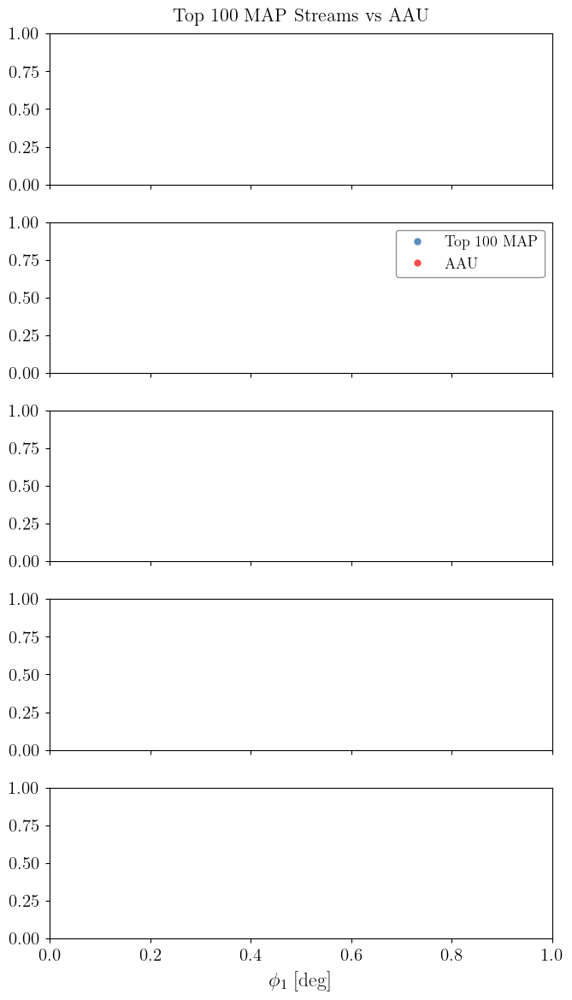

In [49]:
plot_pretty(dpi=175, fontsize=17, labelsize=15, figsize=(8, 10), tex=True)

greek_labels = {
    'phi2': r'$\phi_2$ [deg]',
    'vr':   r'$v_r$ [km/s]',
    'pm1':  r'$\mu_{\phi_1}$ [mas/yr]',
    'pm2':  r'$\mu_{\phi_2}$ [mas/yr]',
    'dist': r'$d$ [kpc]',
}

from matplotlib.lines import Line2D

alphas = np.linspace(0.05, 0.35, 1000)[::-1]   # rank 1 most opaque

fig, axes = plt.subplots(5, 1, figsize=(7, 12), sharex=True)
fig.subplots_adjust(hspace=0.08)

for rank, feats_i in enumerate(top1000_feats):
    phi1_i      = feats_i[:, 0]
    mask_i      = (phi1_i >= phi1_min) & (phi1_i < phi1_max)
    feats_cut_i = feats_i[mask_i]
    phi1_cut_i  = feats_cut_i[:, 0]
    alpha = alphas[rank]
    size  = 3 if rank == 0 else 1

    for j, ax in enumerate(axes):
        ax.scatter(
            phi1_cut_i, feats_cut_i[:, j + 1],
            s=size, c=color_ps, alpha=alpha,
            edgecolors='none', rasterized=True,
        )

# AAU overlay
# for j, ax in enumerate(axes):
#     feat = list(greek_labels.keys())[j]
#     ax.scatter(
#         aau_cut['phi1'].values, aau_cols[feat],
#         s=9, c='#FF4C4C', alpha=1.0, zorder=5,
#         edgecolors='none',
#         label='AAU' if j == 0 else None,
#     )
#     ax.set_ylabel(greek_labels[feat], labelpad=6)
#     ax.yaxis.set_minor_locator(plt.AutoLocator())
#     ax.tick_params(which='both', direction='in', top=True, right=True)

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='steelblue',
           markersize=7, alpha=0.9, label='Top 100 MAP'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#FF4C4C',
           markersize=7, label='AAU'),
]
axes[1].legend(handles=legend_elements, loc='upper right',
               framealpha=0.85, edgecolor='gray', fontsize=13)
axes[-1].set_xlabel(r'$\phi_1$ [deg]', labelpad=6)
axes[0].set_title('Top 100 MAP Streams vs AAU', fontsize=16, pad=10)

plt.tight_layout()
plt.show()

NameError: name 'aau_cut' is not defined

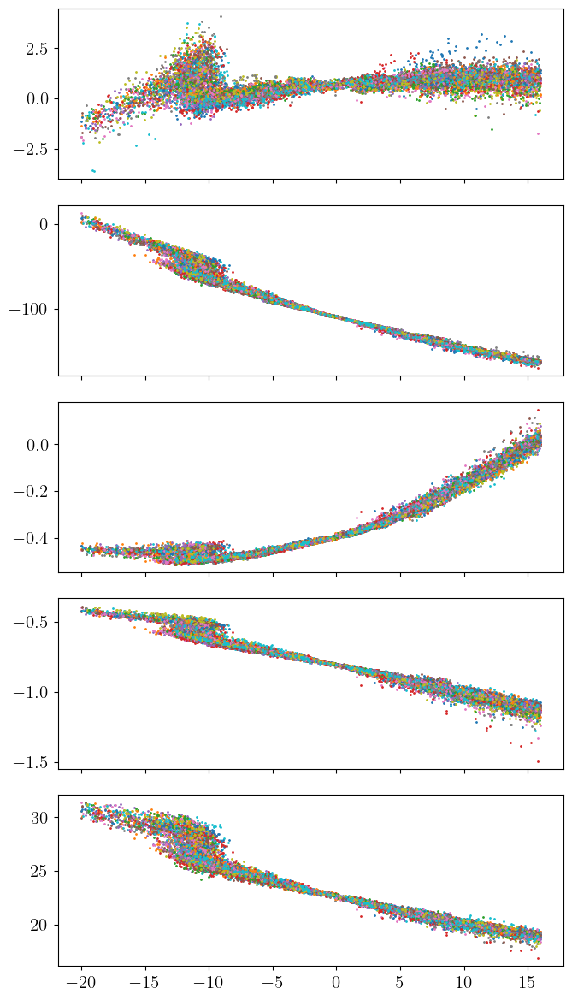

In [50]:
plot_pretty(dpi=175, fontsize=17, labelsize=15, figsize=(8, 10), tex=True)

greek_labels = {
    'phi2': r'$\phi_2$ [deg]',
    'vr':   r'$v_r$ [km/s]',
    'pm1':  r'$\mu_{\phi_1}$ [mas/yr]',
    'pm2':  r'$\mu_{\phi_2}$ [mas/yr]',
    'dist': r'$d$ [kpc]',
}

from matplotlib.lines import Line2D

# First pass: get y-limits from the version WITH AAU
ylims = []
fig_tmp, axes_tmp = plt.subplots(5, 1, figsize=(7, 12), sharex=True)
for rank, feats_i in enumerate(top100_feats):
    phi1_i      = feats_i[:, 0]
    mask_i      = (phi1_i >= phi1_min) & (phi1_i < phi1_max)
    feats_cut_i = feats_i[mask_i]
    for j, ax in enumerate(axes_tmp):
        ax.scatter(feats_cut_i[:, 0], feats_cut_i[:, j + 1], s=1)
for j, ax in enumerate(axes_tmp):
    feat = list(greek_labels.keys())[j]
    ax.scatter(aau_cut['phi1'].values, aau_cols[feat], s=9)
for ax in axes_tmp:
    ylims.append(ax.get_ylim())
plt.close(fig_tmp)

# Real plot: top 100 only, locked y-limits
alphas = np.linspace(0.05, 0.35, 100)[::-1]

fig, axes = plt.subplots(5, 1, figsize=(7, 12), sharex=True)
fig.subplots_adjust(hspace=0.08)

for rank, feats_i in enumerate(top100_feats):
    phi1_i      = feats_i[:, 0]
    mask_i      = (phi1_i >= phi1_min) & (phi1_i < phi1_max)
    feats_cut_i = feats_i[mask_i]
    phi1_cut_i  = feats_cut_i[:, 0]
    alpha = alphas[rank]
    size  = 3 if rank == 0 else 1

    for j, ax in enumerate(axes):
        ax.scatter(
            phi1_cut_i, feats_cut_i[:, j + 1],
            s=size, c=color_ps, alpha=alpha,
            edgecolors='none', rasterized=True,
        )

for j, ax in enumerate(axes):
    ax.set_ylim(ylims[j])          # lock to AAU-inclusive range
    ax.set_ylabel(greek_labels[list(greek_labels.keys())[j]], labelpad=6)
    ax.yaxis.set_minor_locator(plt.AutoLocator())
    ax.tick_params(which='both', direction='in', top=True, right=True)

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=color_ps,
           markersize=7, alpha=0.9, label='Top 100 MAP'),
]
axes[1].legend(handles=legend_elements, loc='upper right',
               framealpha=0.85, edgecolor='gray', fontsize=13)
axes[-1].set_xlabel(r'$\phi_1$ [deg]', labelpad=6)
#axes[0].set_title('Top 100 MAP Streams', fontsize=16, pad=10)

plt.tight_layout()
plt.show()

In [ ]:
# Load PS mock
with open('/global/homes/e/emarin4/scratch/sbi_stream_personal/inference/nbody_mock_829_2000_withuncert.pkl', 'rb') as f:
    data_ps = pickle.load(f)

ps_x   = data_ps[0].x.numpy()    # (N, 9) — [phi1, phi2, vr, pm1, pm2, dist, ...]
ps_pos = data_ps[0].pos.numpy()  # (N, 2) — [phi1, phi2]

# Subsample to 200
idx_sub = np.random.choice(len(ps_x), size=200, replace=False)
ps_x    = ps_x[idx_sub]
ps_pos  = ps_pos[idx_sub]

ps_phi1 = ps_pos[:, 0]
ps_cols = {
    'phi2': ps_x[:, 1],
    'vr':   ps_x[:, 2],
    'pm1':  ps_x[:, 3],
    'pm2':  ps_x[:, 4],
    'dist': ps_x[:, 5],
}

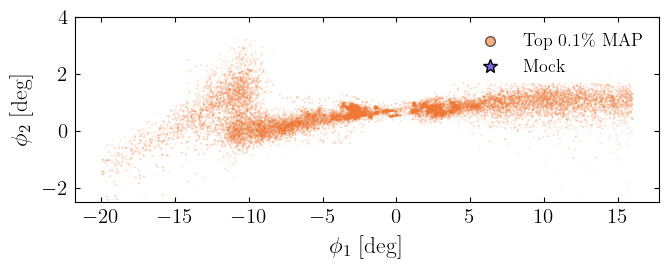

In [ ]:
plot_pretty(dpi=175, fontsize=17, labelsize=15, figsize=(8, 4), tex=True)

from matplotlib.lines import Line2D

alphas = np.linspace(0.05, 0.35, 100)[::-1]

fig, ax = plt.subplots(1, 1, figsize=(7, 3))

for rank, feats_i in enumerate(top100_feats):
    phi1_i      = feats_i[:, 0]
    mask_i      = (phi1_i >= phi1_min) & (phi1_i < phi1_max)
    feats_cut_i = feats_i[mask_i]
    ax.scatter(
        feats_cut_i[:, 0], feats_cut_i[:, 1],
        s=2, c=color_nbody, alpha=alphas[rank],
        edgecolors='none', rasterized=True,
    )

# # Original PS — stars
# ax.scatter(
#     graph_raw.pos[:, 0].numpy(), graph_raw.x[:, 1].numpy(),   # phi1 from pos, phi2 from x col 1
#     s=50, c='mediumslateblue', alpha=0.9, zorder=6,
#     marker='*', edgecolors='none', rasterized=True,
# )

#ax.set_ylim(ylims[0])
ax.set_ylabel(r'$\phi_2$ [deg]', labelpad=6)
ax.set_xlabel(r'$\phi_1$ [deg]', labelpad=6)
ax.yaxis.set_minor_locator(plt.AutoLocator())
ax.tick_params(which='both', direction='in', top=True, right=True)

legend_elements = [
    Line2D([0], [0], marker='o', color='none', markerfacecolor=color_nbody,
           markersize=7, alpha=0.6, label=r'Top 0.1\% MAP'),
    Line2D([0], [0], marker='*', color='none', markerfacecolor='mediumslateblue',
           markersize=10, label='Mock'),
]

ax.legend(handles=legend_elements, loc='upper right',
          framealpha=0.85, edgecolor='none', fontsize=13)
#ax.set_title('Top 100 MAP Streams — Spatial', fontsize=16, pad=10)

plt.ylim(-2.5, 4)
plt.tight_layout()
plt.savefig("top100_map_streams_spatial.png", dpi=300, bbox_inches="tight")
plt.show()

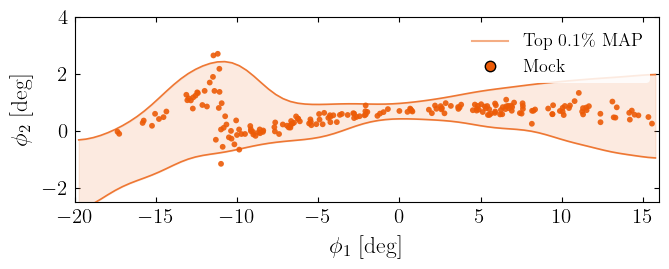

In [ ]:
from matplotlib.lines import Line2D
from scipy.ndimage import gaussian_filter1d

plot_pretty(dpi=175, fontsize=17, labelsize=15, figsize=(8, 4), tex=True)

fig, ax = plt.subplots(1, 1, figsize=(7, 3))

# ── stack all top-100 streams ─────────────────────────────────────────────────
all_phi1, all_phi2 = [], []
for feats_i in top100_feats:
    phi1_i = feats_i[:, 0]
    mask_i = (phi1_i >= phi1_min) & (phi1_i < phi1_max)
    all_phi1.append(feats_i[mask_i, 0])
    all_phi2.append(feats_i[mask_i, 1])

all_phi1 = np.concatenate(all_phi1)
all_phi2 = np.concatenate(all_phi2)

# ── percentile envelope in phi1 bins ─────────────────────────────────────────
n_bins  = 80
edges   = np.linspace(phi1_min, phi1_max, n_bins + 1)
centers = 0.5 * (edges[:-1] + edges[1:])

phi2_lo, phi2_hi = [], []
for l, r in zip(edges[:-1], edges[1:]):
    mask = (all_phi1 >= l) & (all_phi1 < r)
    if mask.sum() >= 5:
        phi2_lo.append(np.percentile(all_phi2[mask], 1))
        phi2_hi.append(np.percentile(all_phi2[mask], 99))
    else:
        phi2_lo.append(np.nan)
        phi2_hi.append(np.nan)

phi2_lo = np.array(phi2_lo)
phi2_hi = np.array(phi2_hi)

valid = ~(np.isnan(phi2_lo) | np.isnan(phi2_hi))
cx    = centers[valid]
lo    = phi2_lo[valid]
hi    = phi2_hi[valid]

color_mock = "#EC5B07"

# ── smooth the edges ──────────────────────────────────────────────────────────
sigma     = 3
lo_smooth = gaussian_filter1d(lo, sigma=sigma)
hi_smooth = gaussian_filter1d(hi, sigma=sigma)

ax.fill_between(cx, lo_smooth, hi_smooth, color=color_nbody, alpha=0.15, zorder=2)
ax.plot(cx, hi_smooth, color=color_nbody, linewidth=1.2, zorder=3)
ax.plot(cx, lo_smooth, color=color_nbody, linewidth=1.2, zorder=3)

# ── mock stars — use graph_raw_full which is the full unsubsampled mock ───────
mock_phi1 = graph_raw.pos[:, 0].numpy()
mock_phi2 = graph_raw.x[:, 1].numpy()
mask_mock = (mock_phi1 >= phi1_min) & (mock_phi1 < phi1_max)
ax.scatter(mock_phi1[mask_mock], mock_phi2[mask_mock],
           s=70, c=color_mock, alpha=0.9, zorder=6,
           marker='.', edgecolors='none', rasterized=True)

# ── style ─────────────────────────────────────────────────────────────────────
ax.set_ylabel(r'$\phi_2$ [deg]', labelpad=6)
ax.set_xlabel(r'$\phi_1$ [deg]', labelpad=6)
ax.set_xlim(phi1_min, phi1_max)
ax.set_ylim(-2.5, 4)
ax.yaxis.set_minor_locator(plt.AutoLocator())
ax.tick_params(which='both', direction='in', top=True, right=True)



legend_elements = [
    Line2D([0], [0], color=color_nbody, linewidth=1.5, alpha=0.6,
           label=r'Top 0.1\% MAP'),
    Line2D([0], [0], marker='.', color='none',
           markerfacecolor=color_mock, markersize=15, label='Mock'),
]
ax.legend(handles=legend_elements, loc='upper right',
          framealpha=0.85, edgecolor='none', fontsize=13)

plt.tight_layout()
plt.savefig("top100_map_streams_envelope.png", dpi=300, bbox_inches="tight")
plt.show()

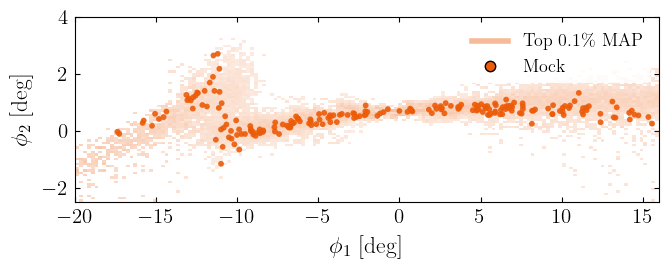

In [ ]:
from matplotlib.lines import Line2D
from matplotlib.colors import LinearSegmentedColormap, PowerNorm
import matplotlib.colors as mcolors

plot_pretty(dpi=175, fontsize=17, labelsize=15, figsize=(8, 4), tex=True)

# ── custom colormap ───────────────────────────────────────────────────────────
cmap_nbody = LinearSegmentedColormap.from_list(
    'white_to_nbody',
    [(0.00, (*mcolors.to_rgb('white'),      0.0)),
     (0.15, (*mcolors.to_rgb(color_nbody),  0.1)),
     (1.00, (*mcolors.to_rgb(color_nbody),  0.5))],
)

# ── stack all top-100 streams ─────────────────────────────────────────────────
all_phi1, all_phi2 = [], []
for feats_i in top100_feats:
    phi1_i = feats_i[:, 0]
    mask_i = (phi1_i >= phi1_min) & (phi1_i < phi1_max)
    all_phi1.append(feats_i[mask_i, 0])
    all_phi2.append(feats_i[mask_i, 1])

all_phi1 = np.concatenate(all_phi1)
all_phi2 = np.concatenate(all_phi2)

# ── phi1-normalised 2D histogram ──────────────────────────────────────────────
def phi1_normalised_hist2d(phi1, feat, bins_phi1=200, bins_feat=100,
                            phi1_range=None, feat_range=None):
    H, xedges, yedges = np.histogram2d(
        phi1, feat,
        bins=[bins_phi1, bins_feat],
        range=[phi1_range, feat_range],
    )
    col_sums = H.sum(axis=1, keepdims=True)
    col_sums[col_sums == 0] = 1
    H_norm = H / col_sums
    return H_norm.T, xedges, yedges

# ── tune these ────────────────────────────────────────────────────────────────
gamma     = 0.25
bins_phi1 = 150
bins_feat = 80
feat_lo   = -2.5
feat_hi   =  4.0

feat_mask = (all_phi2 >= feat_lo) & (all_phi2 <= feat_hi)

H_norm, xedges, yedges = phi1_normalised_hist2d(
    all_phi1[feat_mask], all_phi2[feat_mask],
    bins_phi1=bins_phi1, bins_feat=bins_feat,
    phi1_range=[phi1_min, phi1_max],
    feat_range=[feat_lo, feat_hi],
)

# ── plot ──────────────────────────────────────────────────────────────────────
color_mock = "#EC5B07"

fig, ax = plt.subplots(1, 1, figsize=(7, 3))

ax.pcolormesh(
    xedges, yedges, H_norm,
    cmap=cmap_nbody,
    norm=PowerNorm(gamma=gamma, vmin=0, vmax=H_norm.max()),
    zorder=2, rasterized=True,
)

# ── mock stars ────────────────────────────────────────────────────────────────
mock_phi1 = graph_raw.pos[:, 0].numpy()
mock_phi2 = graph_raw.x[:, 1].numpy()
mask_mock = (mock_phi1 >= phi1_min) & (mock_phi1 < phi1_max)
ax.scatter(mock_phi1[mask_mock], mock_phi2[mask_mock],
           s=70, c=color_mock, alpha=0.9, zorder=6,
           marker='.', edgecolors='none', rasterized=True)

# ── style ─────────────────────────────────────────────────────────────────────
ax.set_ylabel(r'$\phi_2$ [deg]', labelpad=6)
ax.set_xlabel(r'$\phi_1$ [deg]', labelpad=6)
ax.set_xlim(phi1_min, phi1_max)
ax.set_ylim(feat_lo, feat_hi)
ax.yaxis.set_minor_locator(plt.AutoLocator())
ax.tick_params(which='both', direction='in', top=True, right=True)

legend_elements = [
    Line2D([0], [0], color=color_nbody, linewidth=4, alpha=0.5,
           label=r'Top 0.1\% MAP'),
    Line2D([0], [0], marker='.', color='none',
           markerfacecolor=color_mock, markersize=15, label='Mock'),
]
ax.legend(handles=legend_elements, loc='upper right',
          framealpha=0.85, edgecolor='none', fontsize=13)

plt.tight_layout()
plt.savefig("top100_map_streams_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

/tmp/ipykernel_2080172/2648683779.py:203: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig("mock_test.pdf", dpi=300, bbox_inches="tight")
/tmp/ipykernel_2080172/2648683779.py:204: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig("mock_test.png", dpi=300, bbox_inches="tight")
/global/homes/e/emarin4/.conda/envs/sbi-stream/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


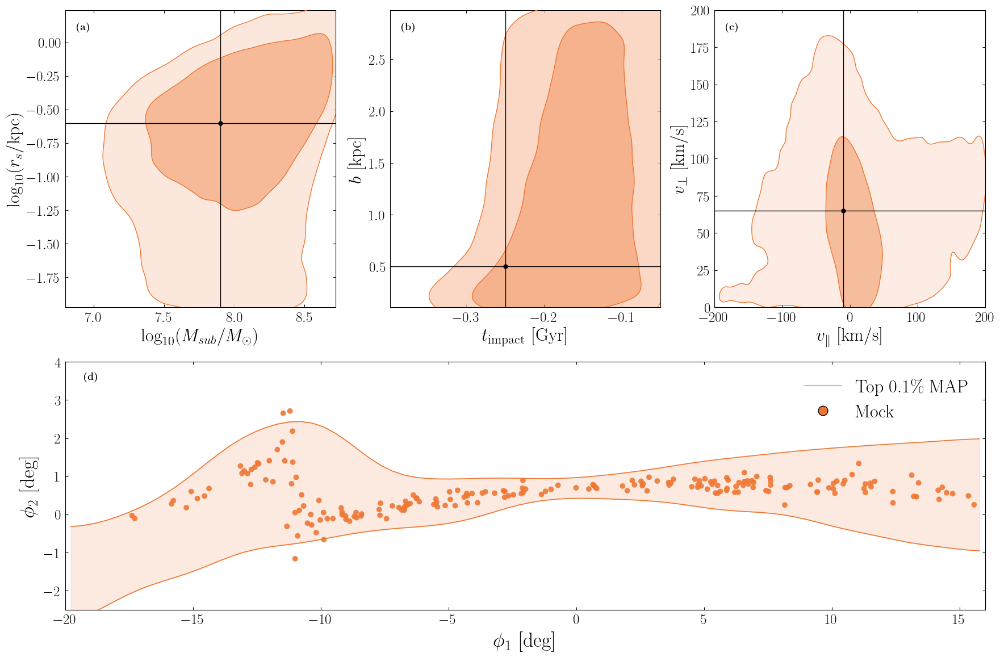

In [ ]:
# ── Paper figure: 3 corner sub-panels (top) + envelope plot (bottom) ──────────
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from scipy.ndimage import gaussian_filter1d
from scipy.stats import gaussian_kde

plot_pretty(dpi=175, fontsize=13, labelsize=11, figsize=(8, 8), tex=True)
plt.close('all')

# ── load cached posterior ─────────────────────────────────────────────────────
_cache        = np.load("corner_cache_nbody.npz", allow_pickle=True)
posterior_sub = _cache["posterior"]
truths_sub    = list(_cache["truths"])
labels_sub    = list(_cache["labels"])

# ── colour / cmap ─────────────────────────────────────────────────────────────
steel   = mcolors.to_rgb(color_nbody)
cmap_sb = mcolors.LinearSegmentedColormap.from_list(
    'white_to_steelblue',
    [(0,   (1, 1, 1)),
     (0.4, (*steel, 0.35)),
     (1.0, (*steel, 0.85))],
)

# ── figure layout ─────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 12))

gs = gridspec.GridSpec(
    2, 1,
    figure=fig,
    height_ratios=[1.2, 1.0],
    hspace=0.20,
    left=0.07, right=0.97,
    top=0.95, bottom=0.07,
)

# top row: 3 corner sub-panels side by side
gs_top = gridspec.GridSpecFromSubplotSpec(
    1, 3,
    subplot_spec=gs[0],
    wspace=0.20,
)

# bottom: envelope plot
ax_env = fig.add_subplot(gs[1])

# ── helper: draw a single 2D posterior panel ──────────────────────────────────
def draw_2d_panel(ax, idx_x, idx_y, xlabel, ylabel,
                  truth_x, truth_y, range_x=None, range_y=None):
    x = posterior_sub[:, idx_x]
    y = posterior_sub[:, idx_y]
 

    # KDE on grid
    if range_x is None: range_x = (np.percentile(x, 0.5), np.percentile(x, 99.5))
    if range_y is None: range_y = (np.percentile(y, 0.5), np.percentile(y, 99.5))

    xg = np.linspace(*range_x, 150)
    yg = np.linspace(*range_y, 150)
    XG, YG = np.meshgrid(xg, yg)

    kde = gaussian_kde(np.vstack([x, y]), bw_method=0.15)
    Z   = kde(np.vstack([XG.ravel(), YG.ravel()])).reshape(XG.shape)

    def dlevel(Z, frac):
        zf = np.sort(Z.ravel())[::-1]
        cs = np.cumsum(zf); cs /= cs[-1]
        return zf[min(np.searchsorted(cs, frac), len(zf)-1)]

    levels = sorted([dlevel(Z, f) for f in [0.95, 0.68]])

    ax.contourf(XG, YG, Z, levels=[levels[0], levels[1], Z.max()*1.01],
                cmap=cmap_sb, zorder=2)
    ax.contour(XG, YG, Z, levels=levels,
               colors=[color_nbody], linewidths=1.0, zorder=3)

    # truth lines
    ax.axvline(truth_x, color='black', linewidth=1.0, zorder=5)
    ax.axhline(truth_y, color='black', linewidth=1.0, zorder=5)
    ax.plot(truth_x, truth_y, 'o', color='black', markersize=5, zorder=6)

    ax.set_xlabel(xlabel, fontsize=23)
    ax.set_ylabel(ylabel, fontsize=23)
    ax.tick_params(which='both', direction='in', top=True, right=True, labelsize=18)
    ax.set_xlim(range_x)
    ax.set_ylim(range_y)

label_info = {
    'log_mass':            (r'$\log_{10}(M_{sub}/M_\odot)$',            None),
    'log_scale_radius':    (r'$\log_{10}(r_s / \mathrm{kpc})$',   None),
    'phi1_impact_today':   (r'$\phi_1^{\rm impact}$ [deg]',        (-15, -8)),
    'time_impact':         (r'$t_{\rm impact}$ [Gyr]',             None),
    'impact_parameter':    (r'$b$ [kpc]',                          None),
    'v_rel_para':          (r'$v_{\parallel}$ [km/s]',   (-200, 200)),
    'v_rel_perp':          (r'$v_{\perp}$ [km/s]',       (0, 200)),
    'angle_pos_at_impact': (r'$\theta_{\rm pos}$ [deg]',           (0, 180)),
    'delta_angle':         (r'$\Delta\theta$ [deg]',               (-90, 90)),
}

def get_idx(name):    return labels_sub.index(name)
def get_truth(name):  return truths_sub[labels_sub.index(name)]
def get_range(name):  return label_info[name][1]
def get_label(name):  return label_info[name][0]

# ── panel 1: log_mass vs log_scale_radius ────────────────────────────────────
ax1 = fig.add_subplot(gs_top[0])
draw_2d_panel(ax1,
    get_idx('log_mass'),         get_idx('log_scale_radius'),
    get_label('log_mass'),       get_label('log_scale_radius'),
    get_truth('log_mass'),       get_truth('log_scale_radius'),
    get_range('log_mass'),       get_range('log_scale_radius'),
)
ax1.text(0.04, 0.96, r'\textbf{(a)}', transform=ax1.transAxes,
         fontsize=13, va='top')

# ── panel 2: time_impact vs impact_parameter ─────────────────────────────────
ax2 = fig.add_subplot(gs_top[1])
draw_2d_panel(ax2,
    get_idx('time_impact'),      get_idx('impact_parameter'),
    get_label('time_impact'),    get_label('impact_parameter'),
    get_truth('time_impact'),    get_truth('impact_parameter'),
    get_range('time_impact'),    get_range('impact_parameter'),
)
ax2.text(0.04, 0.96, r'\textbf{(b)}', transform=ax2.transAxes,
         fontsize=13, va='top')

# ── panel 3: v_rel_para vs v_rel_perp ────────────────────────────────────────
ax3 = fig.add_subplot(gs_top[2])
draw_2d_panel(ax3,
    get_idx('v_rel_para'),       get_idx('v_rel_perp'),
    get_label('v_rel_para'),     get_label('v_rel_perp'),
    get_truth('v_rel_para'),     get_truth('v_rel_perp'),
    get_range('v_rel_para'),     get_range('v_rel_perp'),
)
ax3.text(0.04, 0.96, r'\textbf{(c)}', transform=ax3.transAxes,
         fontsize=13, va='top')

# ── bottom: envelope plot ─────────────────────────────────────────────────────
all_phi1, all_phi2 = [], []
for feats_i in top100_feats:
    phi1_i = feats_i[:, 0]
    mask_i = (phi1_i >= phi1_min) & (phi1_i < phi1_max)
    all_phi1.append(feats_i[mask_i, 0])
    all_phi2.append(feats_i[mask_i, 1])

all_phi1 = np.concatenate(all_phi1)
all_phi2 = np.concatenate(all_phi2)

n_bins  = 80
edges   = np.linspace(phi1_min, phi1_max, n_bins + 1)
centers = 0.5 * (edges[:-1] + edges[1:])

phi2_lo, phi2_hi = [], []
for l, r in zip(edges[:-1], edges[1:]):
    mask = (all_phi1 >= l) & (all_phi1 < r)
    if mask.sum() >= 5:
        phi2_lo.append(np.percentile(all_phi2[mask], 1))
        phi2_hi.append(np.percentile(all_phi2[mask], 99))
    else:
        phi2_lo.append(np.nan)
        phi2_hi.append(np.nan)

phi2_lo = np.array(phi2_lo)
phi2_hi = np.array(phi2_hi)

valid     = ~(np.isnan(phi2_lo) | np.isnan(phi2_hi))
cx        = centers[valid]
lo_smooth = gaussian_filter1d(phi2_lo[valid], sigma=3)
hi_smooth = gaussian_filter1d(phi2_hi[valid], sigma=3)

ax_env.fill_between(cx, lo_smooth, hi_smooth,
                    color=color_nbody, alpha=0.15, zorder=2)
ax_env.plot(cx, hi_smooth, color=color_nbody, linewidth=1.2, zorder=3)
ax_env.plot(cx, lo_smooth, color=color_nbody, linewidth=1.2, zorder=3)

mock_phi1 = graph_raw.pos[:, 0].numpy()
mock_phi2 = graph_raw.x[:, 1].numpy()
mask_mock = (mock_phi1 >= phi1_min) & (mock_phi1 < phi1_max)
ax_env.scatter(mock_phi1[mask_mock], mock_phi2[mask_mock],
               s=50, c=color_nbody, alpha=0.9, zorder=6,
               marker='o', edgecolors='none', rasterized=True)

ax_env.set_ylabel(r'$\phi_2$ [deg]', labelpad=6, fontsize=26)
ax_env.set_xlabel(r'$\phi_1$ [deg]', labelpad=6, fontsize=26)
ax_env.set_xlim(phi1_min, phi1_max)
ax_env.set_ylim(-2.5, 4)
ax_env.yaxis.set_minor_locator(plt.AutoLocator())
ax_env.tick_params(which='both', direction='in', top=True, right=True, labelsize=18)
ax_env.text(0.02, 0.96, r'\textbf{(d)}', transform=ax_env.transAxes,
            fontsize=13, va='top')

legend_elements = [
    Line2D([0], [0], color=color_nbody, linewidth=1.5, alpha=0.6,
           label=r'Top 0.1\% MAP'),
    Line2D([0], [0], marker='o', color='none',
           markerfacecolor=color_nbody, markersize=12,
           label='Mock'),
]
ax_env.legend(handles=legend_elements, loc='upper right',
              framealpha=0.85, edgecolor='none', fontsize=23)

plt.savefig("mock_test.pdf", dpi=300, bbox_inches="tight")
plt.savefig("mock_test.png", dpi=300, bbox_inches="tight")
plt.show()

H_norm max: 0.8056, nonzero bins: 2735


/tmp/ipykernel_2080172/3474990825.py:193: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig("mock_test.pdf", dpi=300, bbox_inches="tight")
/tmp/ipykernel_2080172/3474990825.py:194: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig("mock_test.png", dpi=300, bbox_inches="tight")


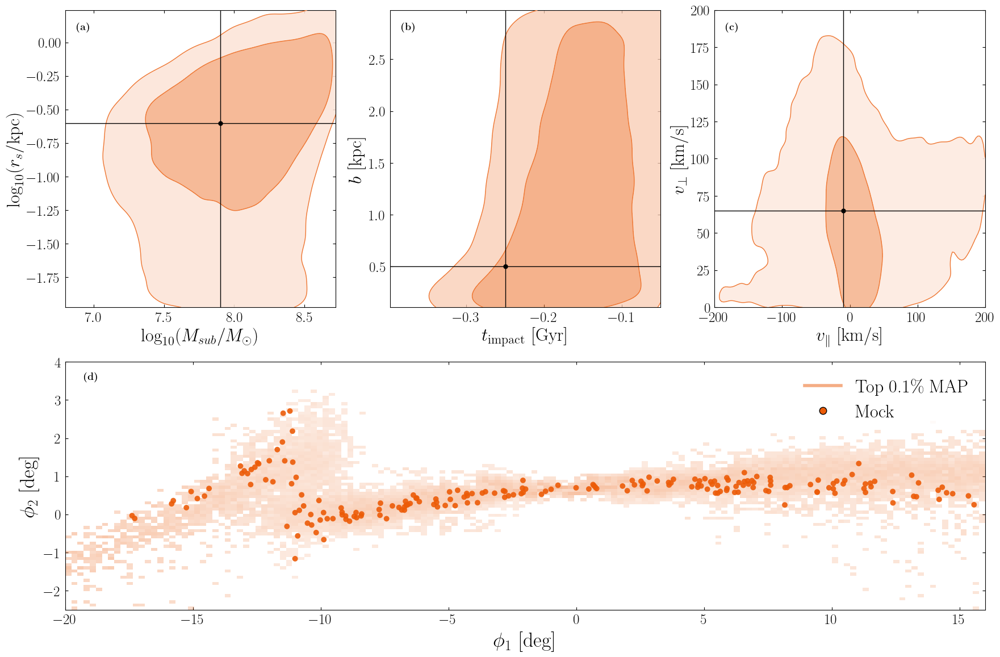

In [ ]:
# ── Paper figure: 3 corner sub-panels (top) + heatmap plot (bottom) ───────────
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from matplotlib.colors import PowerNorm
from scipy.stats import gaussian_kde

plot_pretty(dpi=175, fontsize=13, labelsize=11, figsize=(8, 8), tex=True)
plt.close('all')

# ── load cached posterior ─────────────────────────────────────────────────────
_cache        = np.load("corner_cache_nbody.npz", allow_pickle=True)
posterior_sub = _cache["posterior"]
truths_sub    = list(_cache["truths"])
labels_sub    = list(_cache["labels"])

# ── colour / cmap ─────────────────────────────────────────────────────────────
steel   = mcolors.to_rgb(color_nbody)
cmap_sb = mcolors.LinearSegmentedColormap.from_list(
    'white_to_steelblue',
    [(0,   (1, 1, 1)),
     (0.4, (*steel, 0.35)),
     (1.0, (*steel, 0.85))],
)

cmap_nbody_heat = mcolors.LinearSegmentedColormap.from_list(
    'white_to_nbody',
    [(0.00, (*mcolors.to_rgb('white'),     0.0)),
     (0.15, (*mcolors.to_rgb(color_nbody), 0.1)),
     (1.00, (*mcolors.to_rgb(color_nbody), 0.5))],
)

# ── precompute heatmap ────────────────────────────────────────────────────────
all_phi1_h, all_phi2_h = [], []
for feats_i in top100_feats:
    phi1_i = feats_i[:, 0]
    mask_i = (phi1_i >= phi1_min) & (phi1_i < phi1_max)
    all_phi1_h.append(feats_i[mask_i, 0])
    all_phi2_h.append(feats_i[mask_i, 1])

all_phi1_h = np.concatenate(all_phi1_h)
all_phi2_h = np.concatenate(all_phi2_h)

feat_lo, feat_hi = -2.5, 4.0
feat_mask = (all_phi2_h >= feat_lo) & (all_phi2_h <= feat_hi)

H, xedges, yedges = np.histogram2d(
    all_phi1_h[feat_mask], all_phi2_h[feat_mask],
    bins=[150, 80],
    range=[[phi1_min, phi1_max], [feat_lo, feat_hi]],
)
col_sums = H.sum(axis=1, keepdims=True)
col_sums[col_sums == 0] = 1
H_norm = (H / col_sums).T

print(f"H_norm max: {H_norm.max():.4f}, nonzero bins: {(H_norm > 0).sum()}")

# ── figure layout ─────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 12))

gs = gridspec.GridSpec(
    2, 1,
    figure=fig,
    height_ratios=[1.2, 1.0],
    hspace=0.20,
    left=0.07, right=0.97,
    top=0.95, bottom=0.07,
)

gs_top = gridspec.GridSpecFromSubplotSpec(
    1, 3,
    subplot_spec=gs[0],
    wspace=0.20,
)

ax_env = fig.add_subplot(gs[1])

# ── helper: draw a single 2D posterior panel ──────────────────────────────────
def draw_2d_panel(ax, idx_x, idx_y, xlabel, ylabel,
                  truth_x, truth_y, range_x=None, range_y=None):
    x = posterior_sub[:, idx_x]
    y = posterior_sub[:, idx_y]

    if range_x is None: range_x = (np.percentile(x, 0.5), np.percentile(x, 99.5))
    if range_y is None: range_y = (np.percentile(y, 0.5), np.percentile(y, 99.5))

    xg = np.linspace(*range_x, 150)
    yg = np.linspace(*range_y, 150)
    XG, YG = np.meshgrid(xg, yg)

    kde = gaussian_kde(np.vstack([x, y]), bw_method=0.15)
    Z   = kde(np.vstack([XG.ravel(), YG.ravel()])).reshape(XG.shape)

    def dlevel(Z, frac):
        zf = np.sort(Z.ravel())[::-1]
        cs = np.cumsum(zf); cs /= cs[-1]
        return zf[min(np.searchsorted(cs, frac), len(zf)-1)]

    levels = sorted([dlevel(Z, f) for f in [0.95, 0.68]])

    ax.contourf(XG, YG, Z, levels=[levels[0], levels[1], Z.max()*1.01],
                cmap=cmap_sb, zorder=2)
    ax.contour(XG, YG, Z, levels=levels,
               colors=[color_nbody], linewidths=1.0, zorder=3)

    ax.axvline(truth_x, color='black', linewidth=1.0, zorder=5)
    ax.axhline(truth_y, color='black', linewidth=1.0, zorder=5)
    ax.plot(truth_x, truth_y, 'o', color='black', markersize=5, zorder=6)

    ax.set_xlabel(xlabel, fontsize=23)
    ax.set_ylabel(ylabel, fontsize=23)
    ax.tick_params(which='both', direction='in', top=True, right=True, labelsize=18)
    ax.set_xlim(range_x)
    ax.set_ylim(range_y)

label_info = {
    'log_mass':            (r'$\log_{10}(M_{sub}/M_\odot)$', None),
    'log_scale_radius':    (r'$\log_{10}(r_s / \mathrm{kpc})$', None),
    'phi1_impact_today':   (r'$\phi_1^{\rm impact}$ [deg]', (-15, -8)),
    'time_impact':         (r'$t_{\rm impact}$ [Gyr]', None),
    'impact_parameter':    (r'$b$ [kpc]', None),
    'v_rel_para':          (r'$v_{\parallel}$ [km/s]', (-200, 200)),
    'v_rel_perp':          (r'$v_{\perp}$ [km/s]', (0, 200)),
    'angle_pos_at_impact': (r'$\theta_{\rm pos}$ [deg]', (0, 180)),
    'delta_angle':         (r'$\Delta\theta$ [deg]', (-90, 90)),
}

def get_idx(name):   return labels_sub.index(name)
def get_truth(name): return truths_sub[labels_sub.index(name)]
def get_range(name): return label_info[name][1]
def get_label(name): return label_info[name][0]

ax1 = fig.add_subplot(gs_top[0])
draw_2d_panel(ax1,
    get_idx('log_mass'),       get_idx('log_scale_radius'),
    get_label('log_mass'),     get_label('log_scale_radius'),
    get_truth('log_mass'),     get_truth('log_scale_radius'),
    get_range('log_mass'),     get_range('log_scale_radius'),
)
ax1.text(0.04, 0.96, r'\textbf{(a)}', transform=ax1.transAxes, fontsize=13, va='top')

ax2 = fig.add_subplot(gs_top[1])
draw_2d_panel(ax2,
    get_idx('time_impact'),    get_idx('impact_parameter'),
    get_label('time_impact'),  get_label('impact_parameter'),
    get_truth('time_impact'),  get_truth('impact_parameter'),
    get_range('time_impact'),  get_range('impact_parameter'),
)
ax2.text(0.04, 0.96, r'\textbf{(b)}', transform=ax2.transAxes, fontsize=13, va='top')

ax3 = fig.add_subplot(gs_top[2])
draw_2d_panel(ax3,
    get_idx('v_rel_para'),     get_idx('v_rel_perp'),
    get_label('v_rel_para'),   get_label('v_rel_perp'),
    get_truth('v_rel_para'),   get_truth('v_rel_perp'),
    get_range('v_rel_para'),   get_range('v_rel_perp'),
)
ax3.text(0.04, 0.96, r'\textbf{(c)}', transform=ax3.transAxes, fontsize=13, va='top')

# ── bottom: heatmap ───────────────────────────────────────────────────────────
ax_env.pcolormesh(
    xedges, yedges, H_norm,
    cmap=cmap_nbody_heat,
    norm=PowerNorm(gamma=0.25, vmin=0, vmax=H_norm.max()),
    zorder=2, rasterized=True,
)

mock_phi1 = graph_raw.pos[:, 0].numpy()
mock_phi2 = graph_raw.x[:, 1].numpy()
mask_mock = (mock_phi1 >= phi1_min) & (mock_phi1 < phi1_max)
ax_env.scatter(mock_phi1[mask_mock], mock_phi2[mask_mock],
               s=200, c='#EC5B07', alpha=0.9, zorder=6,
               marker='.', edgecolors='none', rasterized=True)

ax_env.set_ylabel(r'$\phi_2$ [deg]', labelpad=6, fontsize=26)
ax_env.set_xlabel(r'$\phi_1$ [deg]', labelpad=6, fontsize=26)
ax_env.set_xlim(phi1_min, phi1_max)
ax_env.set_ylim(feat_lo, feat_hi)
ax_env.yaxis.set_minor_locator(plt.AutoLocator())
ax_env.tick_params(which='both', direction='in', top=True, right=True, labelsize=18)
ax_env.text(0.02, 0.96, r'\textbf{(d)}', transform=ax_env.transAxes,
            fontsize=13, va='top')

legend_elements = [
    Line2D([0], [0], color=color_nbody, linewidth=4, alpha=0.6,
           label=r'Top 0.1\% MAP'),
    Line2D([0], [0], marker='.', color='none',
           markerfacecolor='#EC5B07', markersize=18, label='Mock'),
]
ax_env.legend(handles=legend_elements, loc='upper right',
              framealpha=0.85, edgecolor='none', fontsize=23)

plt.savefig("mock_test.pdf", dpi=300, bbox_inches="tight")
plt.savefig("mock_test.png", dpi=300, bbox_inches="tight")
plt.show()

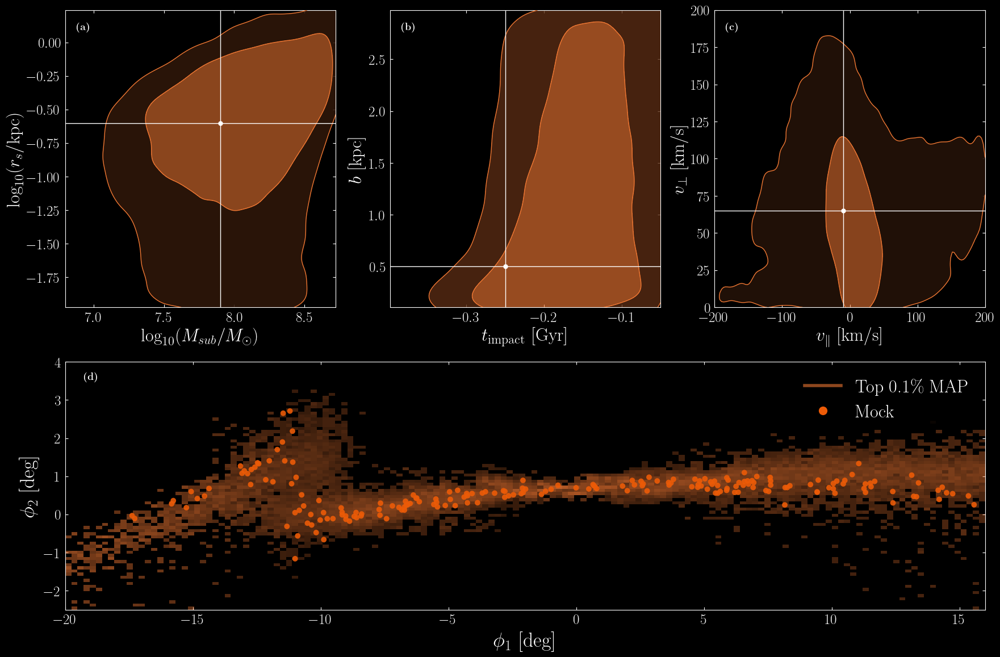

In [ ]:
# ── Paper figure (dark): 3 corner sub-panels (top) + envelope plot (bottom) ──
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from scipy.ndimage import gaussian_filter1d
from scipy.stats import gaussian_kde

plot_pretty(dpi=175, fontsize=13, labelsize=11, figsize=(8, 8), tex=True)
plt.close('all')

# ── dark theme (restored at the end of the cell) ──────────────────────────────
BG = 'k'
FG = "white"
dark_rc = {
    "figure.facecolor":  BG,
    "axes.facecolor":    BG,
    "savefig.facecolor": BG,
    "savefig.edgecolor": BG,
    "axes.edgecolor":    FG,
    "axes.labelcolor":   FG,
    "text.color":        FG,
    "xtick.color":       FG,
    "ytick.color":       FG,
    "legend.facecolor":  BG,
    "legend.labelcolor": FG,
}
_rc_backup = {k: plt.rcParams[k] for k in dark_rc}
plt.rcParams.update(dark_rc)

# ── load cached posterior ─────────────────────────────────────────────────────
_cache        = np.load("corner_cache_nbody.npz", allow_pickle=True)
posterior_sub = _cache["posterior"]
truths_sub    = list(_cache["truths"])
labels_sub    = list(_cache["labels"])

# ── colour / cmap (fades from background into steel blue) ────────────────────
steel   = mcolors.to_rgb(color_nbody)
bg_rgb  = mcolors.to_rgb(BG)
cmap_sb = mcolors.LinearSegmentedColormap.from_list(
    'dark_to_steelblue',
    [(0,   (*bg_rgb, 1.0)),
     (0.4, (*steel, 0.45)),
     (1.0, (*steel, 0.90))],
)

# ── figure layout ─────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 12))

gs = gridspec.GridSpec(
    2, 1,
    figure=fig,
    height_ratios=[1.2, 1.0],
    hspace=0.20,
    left=0.07, right=0.97,
    top=0.95, bottom=0.07,
)

# top row: 3 corner sub-panels side by side
gs_top = gridspec.GridSpecFromSubplotSpec(
    1, 3,
    subplot_spec=gs[0],
    wspace=0.20,
)

# bottom: envelope plot
ax_env = fig.add_subplot(gs[1])

# ── helper: draw a single 2D posterior panel ──────────────────────────────────
def draw_2d_panel(ax, idx_x, idx_y, xlabel, ylabel,
                  truth_x, truth_y, range_x=None, range_y=None):
    x = posterior_sub[:, idx_x]
    y = posterior_sub[:, idx_y]

    # KDE on grid
    if range_x is None: range_x = (np.percentile(x, 0.5), np.percentile(x, 99.5))
    if range_y is None: range_y = (np.percentile(y, 0.5), np.percentile(y, 99.5))

    xg = np.linspace(*range_x, 150)
    yg = np.linspace(*range_y, 150)
    XG, YG = np.meshgrid(xg, yg)

    kde = gaussian_kde(np.vstack([x, y]), bw_method=0.15)
    Z   = kde(np.vstack([XG.ravel(), YG.ravel()])).reshape(XG.shape)

    def dlevel(Z, frac):
        zf = np.sort(Z.ravel())[::-1]
        cs = np.cumsum(zf); cs /= cs[-1]
        return zf[min(np.searchsorted(cs, frac), len(zf)-1)]

    levels = sorted([dlevel(Z, f) for f in [0.95, 0.68]])

    ax.contourf(XG, YG, Z, levels=[levels[0], levels[1], Z.max()*1.01],
                cmap=cmap_sb, zorder=2)
    ax.contour(XG, YG, Z, levels=levels,
               colors=[color_nbody], linewidths=1.0, zorder=3)

    # truth lines
    ax.axvline(truth_x, color=FG, linewidth=1.0, zorder=5)
    ax.axhline(truth_y, color=FG, linewidth=1.0, zorder=5)
    ax.plot(truth_x, truth_y, 'o', color=FG, markersize=5, zorder=6)

    ax.set_xlabel(xlabel, fontsize=23)
    ax.set_ylabel(ylabel, fontsize=23)
    ax.tick_params(which='both', direction='in', top=True, right=True, labelsize=18)
    ax.set_xlim(range_x)
    ax.set_ylim(range_y)

label_info = {
    'log_mass':            (r'$\log_{10}(M_{sub}/M_\odot)$',            None),
    'log_scale_radius':    (r'$\log_{10}(r_s / \mathrm{kpc})$',   None),
    'phi1_impact_today':   (r'$\phi_1^{\rm impact}$ [deg]',        (-15, -8)),
    'time_impact':         (r'$t_{\rm impact}$ [Gyr]',             None),
    'impact_parameter':    (r'$b$ [kpc]',                          None),
    'v_rel_para':          (r'$v_{\parallel}$ [km/s]',   (-200, 200)),
    'v_rel_perp':          (r'$v_{\perp}$ [km/s]',       (0, 200)),
    'angle_pos_at_impact': (r'$\theta_{\rm pos}$ [deg]',           (0, 180)),
    'delta_angle':         (r'$\Delta\theta$ [deg]',               (-90, 90)),
}

def get_idx(name):    return labels_sub.index(name)
def get_truth(name):  return truths_sub[labels_sub.index(name)]
def get_range(name):  return label_info[name][1]
def get_label(name):  return label_info[name][0]

# ── panel 1: log_mass vs log_scale_radius ────────────────────────────────────
ax1 = fig.add_subplot(gs_top[0])
draw_2d_panel(ax1,
    get_idx('log_mass'),         get_idx('log_scale_radius'),
    get_label('log_mass'),       get_label('log_scale_radius'),
    get_truth('log_mass'),       get_truth('log_scale_radius'),
    get_range('log_mass'),       get_range('log_scale_radius'),
)
ax1.text(0.04, 0.96, r'\textbf{(a)}', transform=ax1.transAxes,
         fontsize=13, va='top')

# ── panel 2: time_impact vs impact_parameter ─────────────────────────────────
ax2 = fig.add_subplot(gs_top[1])
draw_2d_panel(ax2,
    get_idx('time_impact'),      get_idx('impact_parameter'),
    get_label('time_impact'),    get_label('impact_parameter'),
    get_truth('time_impact'),    get_truth('impact_parameter'),
    get_range('time_impact'),    get_range('impact_parameter'),
)
ax2.text(0.04, 0.96, r'\textbf{(b)}', transform=ax2.transAxes,
         fontsize=13, va='top')

# ── panel 3: v_rel_para vs v_rel_perp ────────────────────────────────────────
ax3 = fig.add_subplot(gs_top[2])
draw_2d_panel(ax3,
    get_idx('v_rel_para'),       get_idx('v_rel_perp'),
    get_label('v_rel_para'),     get_label('v_rel_perp'),
    get_truth('v_rel_para'),     get_truth('v_rel_perp'),
    get_range('v_rel_para'),     get_range('v_rel_perp'),
)
ax3.text(0.04, 0.96, r'\textbf{(c)}', transform=ax3.transAxes,
         fontsize=13, va='top')

# ── bottom: phi1-normalised heatmap ───────────────────────────────────────────
from matplotlib.colors import LinearSegmentedColormap, PowerNorm

nbody_rgb = mcolors.to_rgb(color_nbody)
cmap_nbody_heat = LinearSegmentedColormap.from_list(
    'clear_to_nbody',
    [(0.00, (*nbody_rgb, 0.0)),
     (0.15, (*nbody_rgb, 0.15)),
     (1.00, (*nbody_rgb, 0.8))],
)

all_phi1, all_phi2 = [], []
for feats_i in top100_feats:
    phi1_i = feats_i[:, 0]
    mask_i = (phi1_i >= phi1_min) & (phi1_i < phi1_max)
    all_phi1.append(feats_i[mask_i, 0])
    all_phi2.append(feats_i[mask_i, 1])

all_phi1 = np.concatenate(all_phi1)
all_phi2 = np.concatenate(all_phi2)

gamma     = 0.25
bins_phi1 = 150
bins_feat = 80
feat_lo   = -2.5
feat_hi   =  4.0

feat_mask = (all_phi2 >= feat_lo) & (all_phi2 <= feat_hi)

H, xedges, yedges = np.histogram2d(
    all_phi1[feat_mask], all_phi2[feat_mask],
    bins=[bins_phi1, bins_feat],
    range=[[phi1_min, phi1_max], [feat_lo, feat_hi]],
)
col_sums = H.sum(axis=1, keepdims=True)
col_sums[col_sums == 0] = 1
H_norm = (H / col_sums).T

ax_env.pcolormesh(
    xedges, yedges, H_norm,
    cmap=cmap_nbody_heat,
    norm=PowerNorm(gamma=gamma, vmin=0, vmax=H_norm.max()),
    zorder=2, rasterized=True,
)

# ── mock stars ────────────────────────────────────────────────────────────────
mock_phi1 = graph_raw.pos[:, 0].numpy()
mock_phi2 = graph_raw.x[:, 1].numpy()
mask_mock = (mock_phi1 >= phi1_min) & (mock_phi1 < phi1_max)
ax_env.scatter(mock_phi1[mask_mock], mock_phi2[mask_mock],
               s=50, c='#EC5B07', alpha=0.9, zorder=6,
               marker='o', edgecolors='none', rasterized=True)

ax_env.set_ylabel(r'$\phi_2$ [deg]', labelpad=6, fontsize=26)
ax_env.set_xlabel(r'$\phi_1$ [deg]', labelpad=6, fontsize=26)
ax_env.set_xlim(phi1_min, phi1_max)
ax_env.set_ylim(feat_lo, feat_hi)
ax_env.yaxis.set_minor_locator(plt.AutoLocator())
ax_env.tick_params(which='both', direction='in', top=True, right=True, labelsize=18)
ax_env.text(0.02, 0.96, r'\textbf{(d)}', transform=ax_env.transAxes,
            fontsize=13, va='top')

legend_elements = [
    Line2D([0], [0], color=color_nbody, linewidth=4, alpha=0.6,
           label=r'Top 0.1\% MAP'),
    Line2D([0], [0], marker='o', color='none',
           markerfacecolor='#EC5B07', markersize=12,
           label='Mock'),
]
ax_env.legend(handles=legend_elements, loc='upper right',
              framealpha=0.85, edgecolor='none', fontsize=23)

In [105]:
print(f"H_norm max: {H_norm.max():.4f}")
print(f"H_norm nonzero: {(H_norm > 0).sum()}")
print(f"all_phi1 range: {all_phi1.min():.2f} to {all_phi1.max():.2f}")
print(f"all_phi2 range: {all_phi2.min():.2f} to {all_phi2.max():.2f}")

H_norm max: 0.7755
H_norm nonzero: 2612
all_phi1 range: -20.00 to 16.00
all_phi2 range: -3.40 to 3.54


/tmp/ipykernel_808288/503934821.py:158: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig("paper_corner_plus_spatial.pdf", dpi=300, bbox_inches="tight")
/tmp/ipykernel_808288/503934821.py:158: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig("paper_corner_plus_spatial.pdf", dpi=300, bbox_inches="tight")
/tmp/ipykernel_808288/503934821.py:159: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig("paper_corner_plus_spatial.png", dpi=300, bbox_inches="tight")
/tmp/ipykernel_808288/503934821.py:159: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig("paper_corner_plus_spatial.png", dpi=300, bbox_inches="tight")
/global/homes/e/emarin4/.conda/envs/sbi-stream/lib/python3.10/site-packages/IPyt

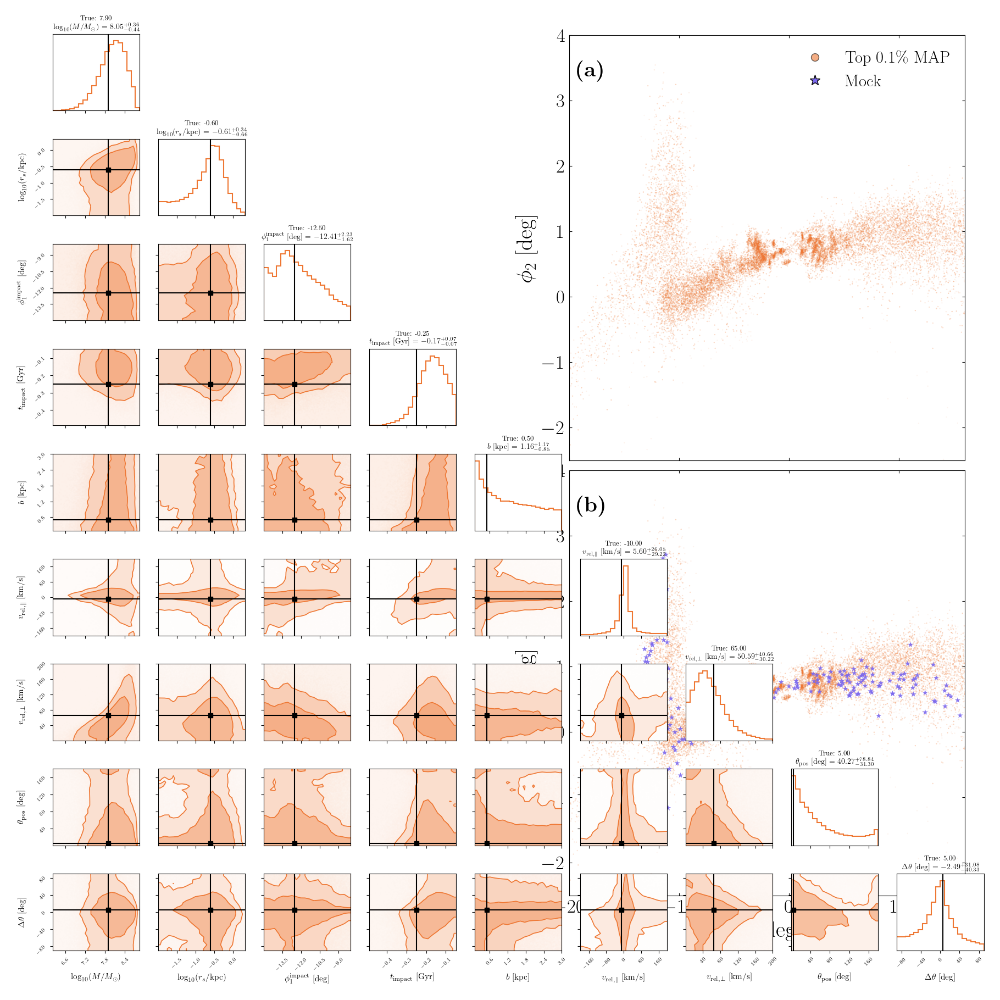

In [74]:
# ── Combined figure: corner (left) + two φ₁–φ₂ panels (right) ────────────────
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D

DRAFT = False

plot_pretty(dpi=175, fontsize=13, labelsize=11, figsize=(8, 8), tex=True)
plt.close('all')

# ── load cached posterior ─────────────────────────────────────────────────────
_cache        = np.load("corner_cache_nbody.npz", allow_pickle=True)
posterior_sub = _cache["posterior"]
truths_sub    = list(_cache["truths"])
labels_sub    = list(_cache["labels"])

# ── colour / cmap ─────────────────────────────────────────────────────────────
steel   = mcolors.to_rgb(color_nbody)
cmap_sb = mcolors.LinearSegmentedColormap.from_list(
    'white_to_steelblue',
    [(0,   (1, 1, 1)),
     (0.4, (*steel, 0.35)),
     (1.0, (*steel, 0.85))],
)

label_info = {
    'log_mass':            (r'$\log_{10}(M/M_\odot)$',            None),
    'log_scale_radius':    (r'$\log_{10}(r_s / \mathrm{kpc})$',   None),
    'phi1_impact_today':   (r'$\phi_1^{\rm impact}$ [deg]',        (-15, -8)),
    'time_impact':         (r'$t_{\rm impact}$ [Gyr]',             None),
    'impact_parameter':    (r'$b$ [kpc]',                          None),
    'v_rel_para':          (r'$v_{{\rm rel},\parallel}$ [km/s]',   (-200, 200)),
    'v_rel_perp':          (r'$v_{{\rm rel},\perp}$ [km/s]',       (0, 200)),
    'angle_pos_at_impact': (r'$\theta_{\rm pos}$ [deg]',           (0, 180)),
    'delta_angle':         (r'$\Delta\theta$ [deg]',               (-90, 90)),
}
labels_display = [label_info[l][0] for l in labels_sub]
plot_range     = [label_info[l][1] if label_info[l][1] is not None else 0.999
                  for l in labels_sub]

# ── canvas ────────────────────────────────────────────────────────────────────
N     = len(labels_sub)
fig_w = 18
fig_h = 18

fig = plt.figure(figsize=(fig_w, fig_h))

corner_frac = 0.60
corner_vert = corner_frac * fig_w / fig_h

corner_subfig = fig.add_subfigure(
    gridspec.GridSpec(1, 1, left=0.0, right=corner_frac,
                      top=1.0, bottom=1.0 - corner_vert)[0]
)

right_subfig = fig.add_subfigure(
    gridspec.GridSpec(1, 1, left=corner_frac, right=1.0,
                      top=1.0, bottom=0.0)[0]
)

# ── corner plot ───────────────────────────────────────────────────────────────
if not DRAFT:
    corner.corner(
        posterior_sub,
        truths          = truths_sub,
        labels          = labels_display,
        show_titles     = True,
        title_fmt       = ".2f",
        truth_color     = 'black',
        color           = color_nbody,
        fill_contours   = True,
        levels          = [0.68, 0.95],
        hist_kwargs     = {"color": color_nbody, "linewidth": 1.5},
        contour_kwargs  = {"colors": [color_nbody], "linewidths": 1.2},
        contourf_kwargs = {"cmap": cmap_sb, "colors": None},
        label_kwargs    = {"fontsize": 11},
        title_kwargs    = {"fontsize": 10},
        range           = plot_range,
        fig             = corner_subfig,
    )
    diag_axes = [corner_subfig.axes[i * N + i] for i in range(N)]
    for ax, tv in zip(diag_axes, truths_sub):
        ax.text(0.5, 1.15, f"True: {tv:.2f}",
                color='black', ha='center', va='bottom',
                transform=ax.transAxes, fontsize=9)
    for ax in corner_subfig.axes:
        ax.tick_params(labelsize=7)
else:
    corner_subfig.text(0.5, 0.5, '[corner placeholder]',
                       ha='center', va='center', fontsize=20,
                       transform=corner_subfig.transFigure)

 # ── two sky panels: shared x-axis, stacked ───────────────────────────────────
P_LEFT   = 0.57
P_WIDTH  = 0.40
P_TOP_B  = 0.54   # bottom of top panel
P_TOP_T  = 0.97   # top of top panel
P_BOT_B  = 0.10   # bottom of bottom panel
P_BOT_T  = 0.53   # top of bottom panel (just below top panel)

ax_nosim = fig.add_axes([P_LEFT, P_TOP_B, P_WIDTH, P_TOP_T - P_TOP_B])
ax_mock  = fig.add_axes([P_LEFT, P_BOT_B, P_WIDTH, P_BOT_T - P_BOT_B])

# shared x-axis: hide top panel's x tick labels
ax_nosim.tick_params(labelbottom=False)

alphas = np.linspace(0.05, 0.35, 100)[::-1]

def _draw_top100(ax):
    for rank, feats_i in enumerate(top100_feats):
        phi1_i = feats_i[:, 0]
        mask_i = (phi1_i >= phi1_min) & (phi1_i < phi1_max)
        fc     = feats_i[mask_i]
        ax.scatter(fc[:, 0], fc[:, 1],
                   s=3, c=color_nbody, alpha=alphas[rank],
                   edgecolors='none', rasterized=True)

def _style_panel(ax, xlabel=True):
    ax.set_ylabel(r'$\phi_2$ [deg]', labelpad=5, fontsize=30)
    ax.set_xlim(phi1_min, phi1_max)
    ax.set_ylim(-2.5, 4)
    ax.yaxis.set_minor_locator(plt.AutoLocator())
    ax.tick_params(which='both', direction='in', top=True, right=True, labelsize=25)
    if xlabel:
        ax.set_xlabel(r'$\phi_1$ [deg]', labelpad=5, fontsize=30)

# panel (a) — sims only, legend here
_draw_top100(ax_nosim)
_style_panel(ax_nosim, xlabel=False)
ax_nosim.legend(
    handles=[
        Line2D([0], [0], marker='o', color='none',
               markerfacecolor=color_nbody, markersize=10, alpha=0.6,
               label=r'Top 0.1\% MAP'),
        Line2D([0], [0], marker='*', color='none',
               markerfacecolor='mediumslateblue', markersize=14,
               label='Mock'),
    ],
    loc='upper right', framealpha=0.85, edgecolor='none', fontsize=22,
)
ax_nosim.text(0.02, 0.94, r'\textbf{(a)}',
              transform=ax_nosim.transAxes, fontsize=28, va='top')

# panel (b) — sims + mock, no legend, shared x label
_draw_top100(ax_mock)

mock_phi1 = graph_raw.pos[:, 0].numpy()
mock_phi2 = graph_raw.x[:, 1].numpy()
mask_mock = (mock_phi1 >= phi1_min) & (mock_phi1 < phi1_max)
ax_mock.scatter(mock_phi1[mask_mock], mock_phi2[mask_mock],
                s=60, c='mediumslateblue', alpha=0.9, zorder=6,
                marker='*', edgecolors='none', rasterized=True)

_style_panel(ax_mock, xlabel=True)
ax_mock.text(0.02, 0.94, r'\textbf{(b)}',
             transform=ax_mock.transAxes, fontsize=28, va='top')

plt.savefig("paper_corner_plus_spatial.pdf", dpi=300, bbox_inches="tight")
plt.savefig("paper_corner_plus_spatial.png", dpi=300, bbox_inches="tight")
plt.show()

In [74]:
# import numpy as np

# np.savez(
#     "contours_withuncert_newnorm.npz",
#     posterior=posterior_sub,
#     truths=np.array(truths_sub),
#     labels=np.array(labels_sub),
# )
# print("Saved contours_withuncert_newnorm.npz")

In [75]:
# import numpy as np
# from matplotlib.lines import Line2D
# from matplotlib.patches import Patch

# ALL_RUNS = {
#     "no uncert, old norm":   ("/global/homes/e/emarin4/scratch/sbi_stream_personal/inference/contours_nouncert_oldnorm.npz", "#7b68c4"),
#     "no uncert, new norm":   ("/global/homes/e/emarin4/scratch/sbi_stream_personal/inference/contours_nouncert_newnorm.npz", "#7fae5c"),
#     "with uncert, old norm": ("/global/homes/e/emarin4/scratch/sbi_stream_personal/inference/contours_wuncert_oldnorm.npz", "#4bacc0"),
#     "with uncert, new norm": ("/global/homes/e/emarin4/scratch/sbi_stream_personal/inference/contours_withuncert_newnorm.npz", "#c0504d"),
# }

# label_info = {
#     'log_mass':             (r'$\log_{10}(M/M_\odot)$', None),
#     'log_scale_radius':     (r'$\log_{10}(r_s / \mathrm{kpc})$', None),
#     'phi1_impact_today':    (r'$\phi_1^{\rm impact}$ [deg]', (-15, -8)),
#     'time_impact':          (r'$t_{\rm impact}$ [Gyr]', None),
#     'log_impact_parameter': (r'$\log_{10}(b / \mathrm{kpc})$', None),
#     'v_rel_para':           (r'$v_{\rm rel,\parallel}$ [km/s]', (-200, 200)),
#     'v_rel_perp':           (r'$v_{\rm rel,\perp}$ [km/s]', (0, 200)),
#     'angle_pos_at_impact':  (r'$\theta_{\rm pos}$ [deg]', (0, 180)),
#     'delta_angle':          (r'$\Delta\theta$ [deg]', (-90, 90)),
# }

# labels_display = [label_info[l][0] for l in labels_sub]
# plot_range = [label_info[l][1] if label_info[l][1] is not None else 0.9999 for l in labels_sub]


# def plot_comparison_corner(run_names, title=None):
#     plt.close('all')
#     fig = plt.figure(figsize=(22, 22))

#     for name in run_names:
#         path, color = ALL_RUNS[name]
#         saved = np.load(path, allow_pickle=True)
#         posterior = saved["posterior"]
#         saved_labels = list(saved["labels"])

#         if saved_labels != labels_sub:
#             raise ValueError(f"Label mismatch in {path}: {saved_labels} != {labels_sub}")

#         fig = corner.corner(
#             posterior,
#             labels=labels_display,
#             range=plot_range,
#             color=ALL_RUNS[name][1],
#             fig=fig,
#             show_titles=False,
#             plot_datapoints=False,
#             fill_contours=True,
#             plot_density=False,
#             levels=(0.6827, 0.9545),
#             smooth=1.0,
#             hist_kwargs={"alpha": 0.8, "linewidth": 1.8},
#         )

#     n_params = len(labels_sub)
#     truth_color = "#1f77ff"

#     for row in range(n_params):
#         for col in range(row + 1):
#             ax = fig.axes[row * n_params + col]
#             if row == col:
#                 ax.axvline(truths_sub[col], color=truth_color, lw=1.5, zorder=10)
#             else:
#                 ax.axvline(truths_sub[col], color=truth_color, lw=1.2, zorder=10)
#                 ax.axhline(truths_sub[row], color=truth_color, lw=1.2, zorder=10)
#                 # small square marker at the crosshair intersection
#                 ax.plot(
#                     truths_sub[col], truths_sub[row],
#                     marker="s", markersize=6,
#                     markerfacecolor=truth_color, markeredgecolor="black",
#                     markeredgewidth=0.8, zorder=11,
#                 )

#     legend_elements = [Patch(facecolor=ALL_RUNS[name][1], edgecolor=ALL_RUNS[name][1], alpha=0.6, label=name) for name in run_names]
#     legend_elements.append(Line2D([0], [0], color=truth_color, lw=1.5, marker="s", markersize=6,
#                                     markerfacecolor=truth_color, markeredgecolor="black", label="true value"))
#     fig.axes[n_params - 1].legend(handles=legend_elements, loc="upper right", fontsize=12)

#     if title:
#         fig.suptitle(title, fontsize=18, y=1.01)

#     plt.tight_layout()
#     plt.show()
#     return fig

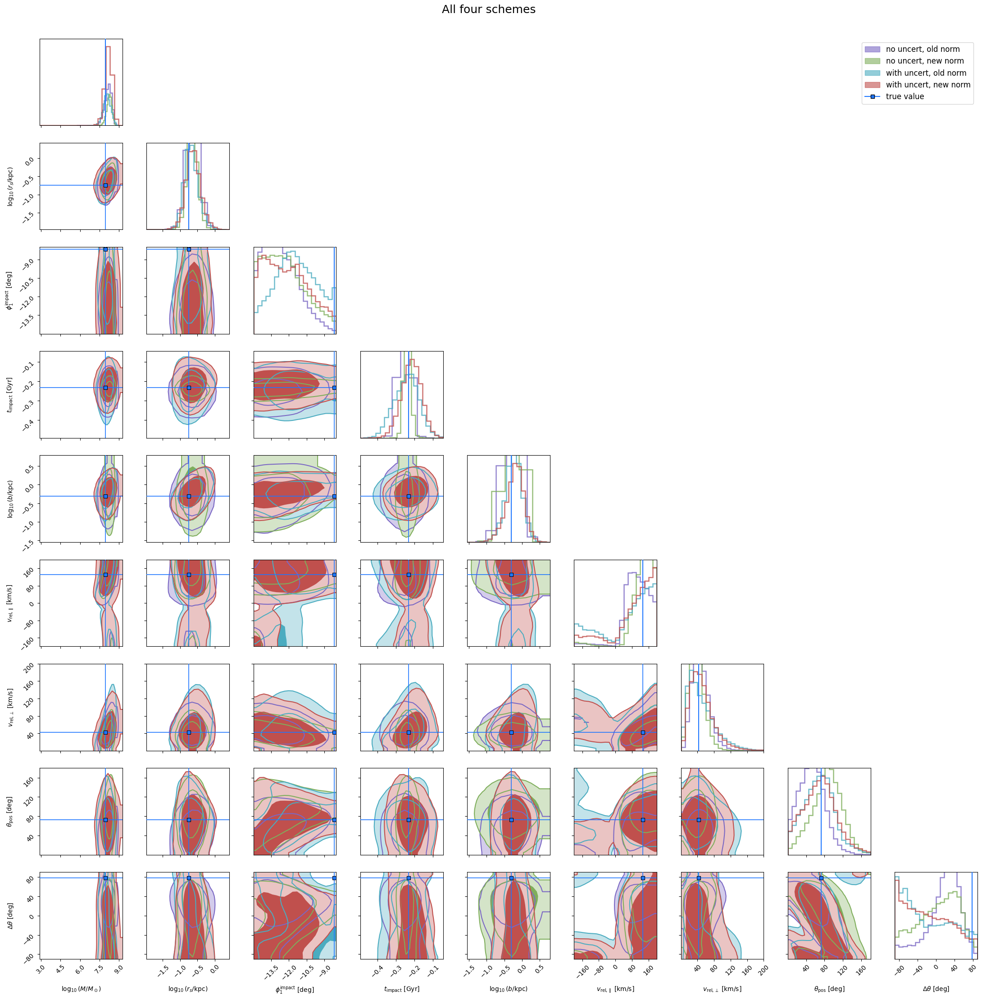

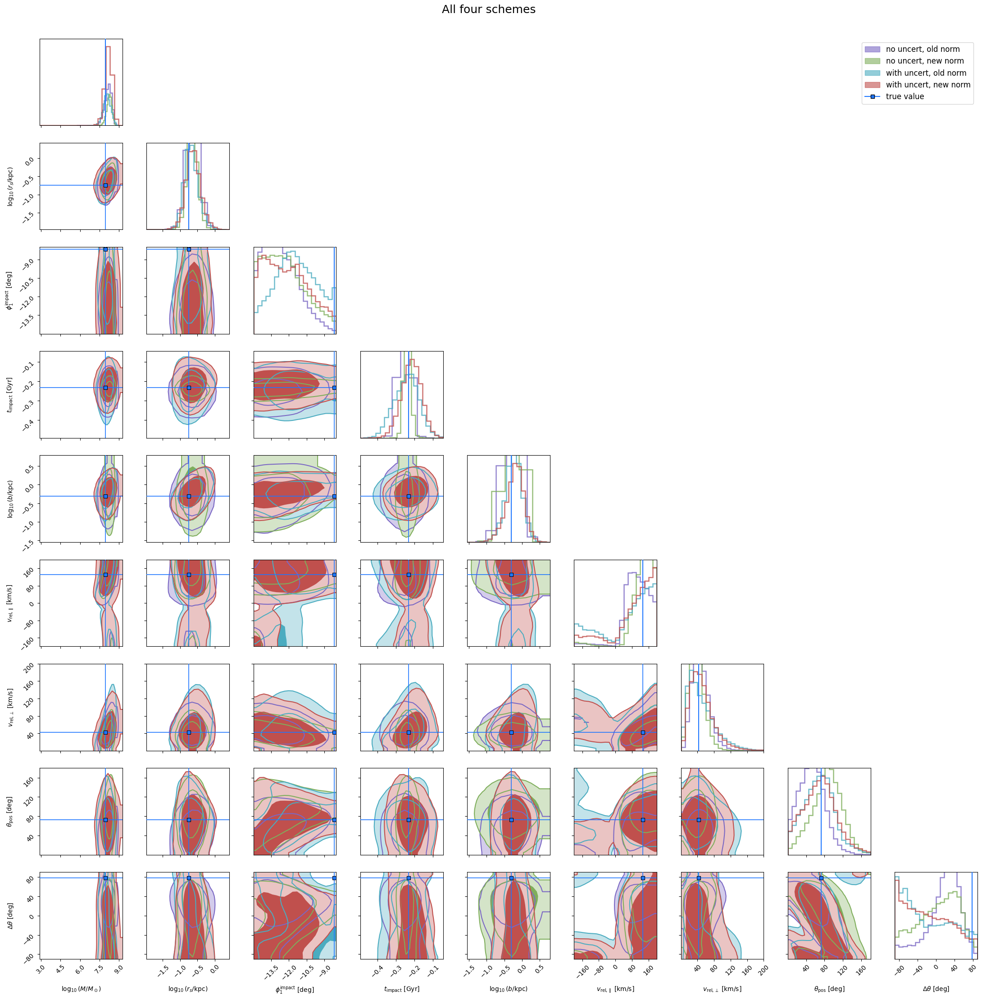

In [ ]:
# plot_comparison_corner(list(ALL_RUNS.keys()), title="All four schemes")

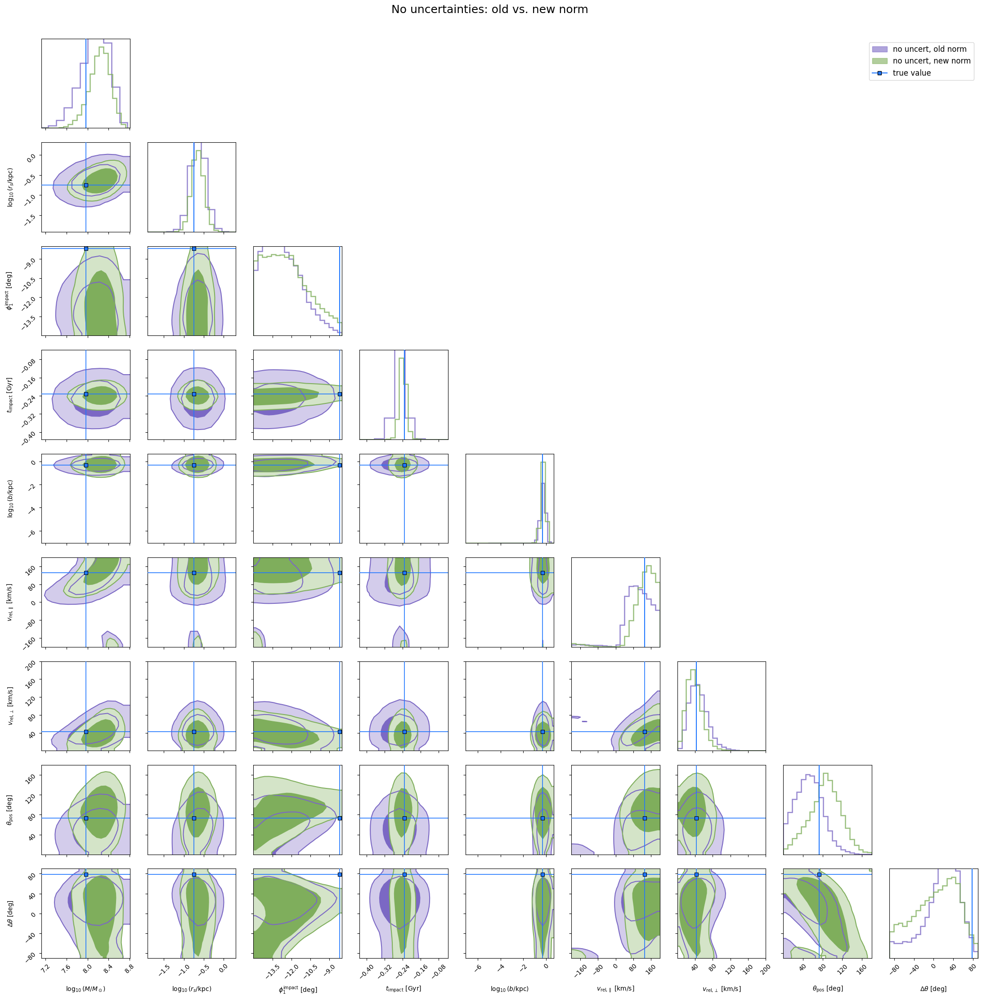

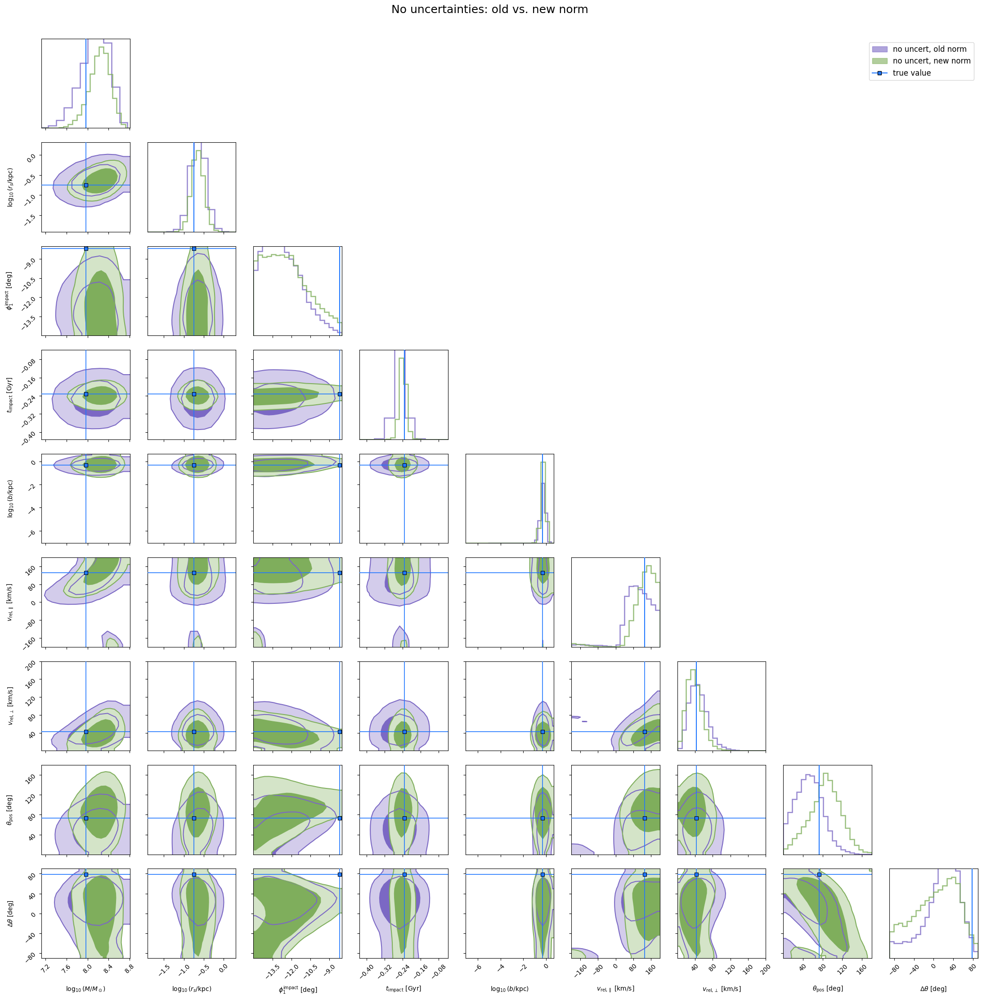

In [ ]:
# plot_comparison_corner(["no uncert, old norm", "no uncert, new norm"], title="No uncertainties: old vs. new norm")

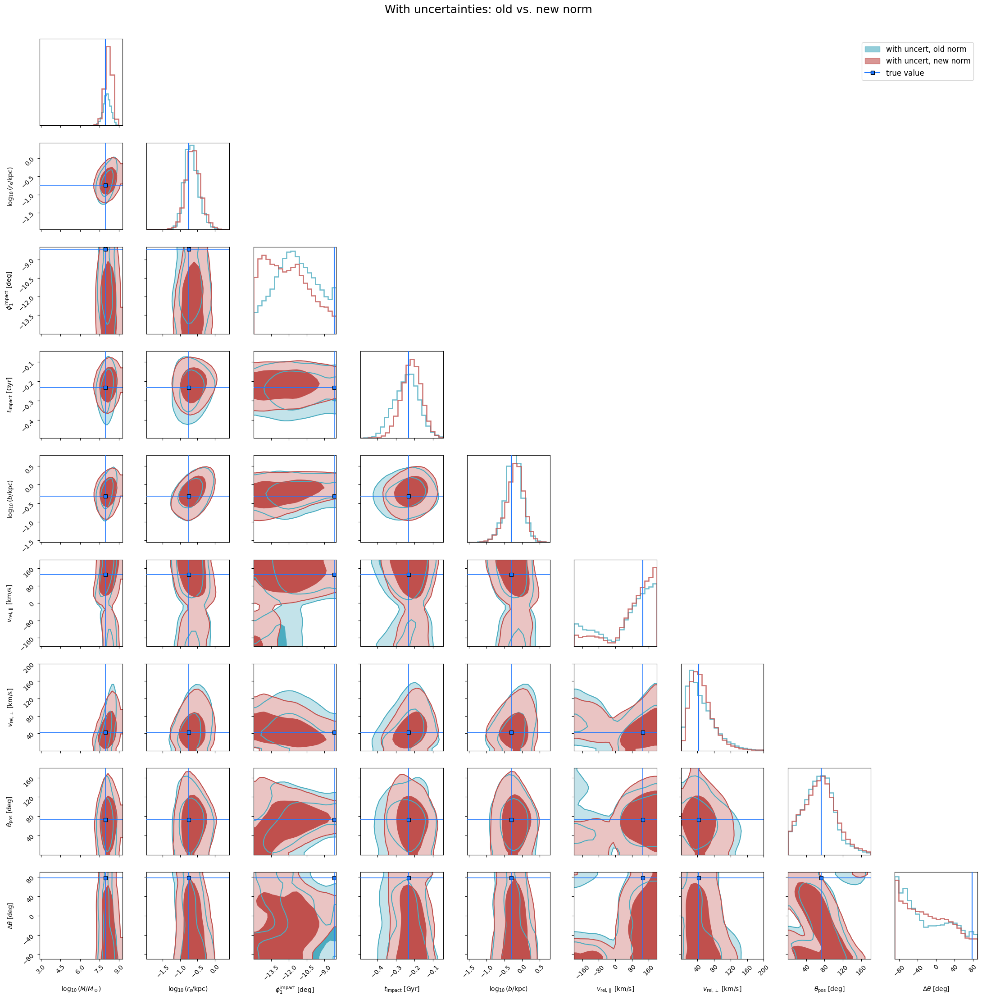

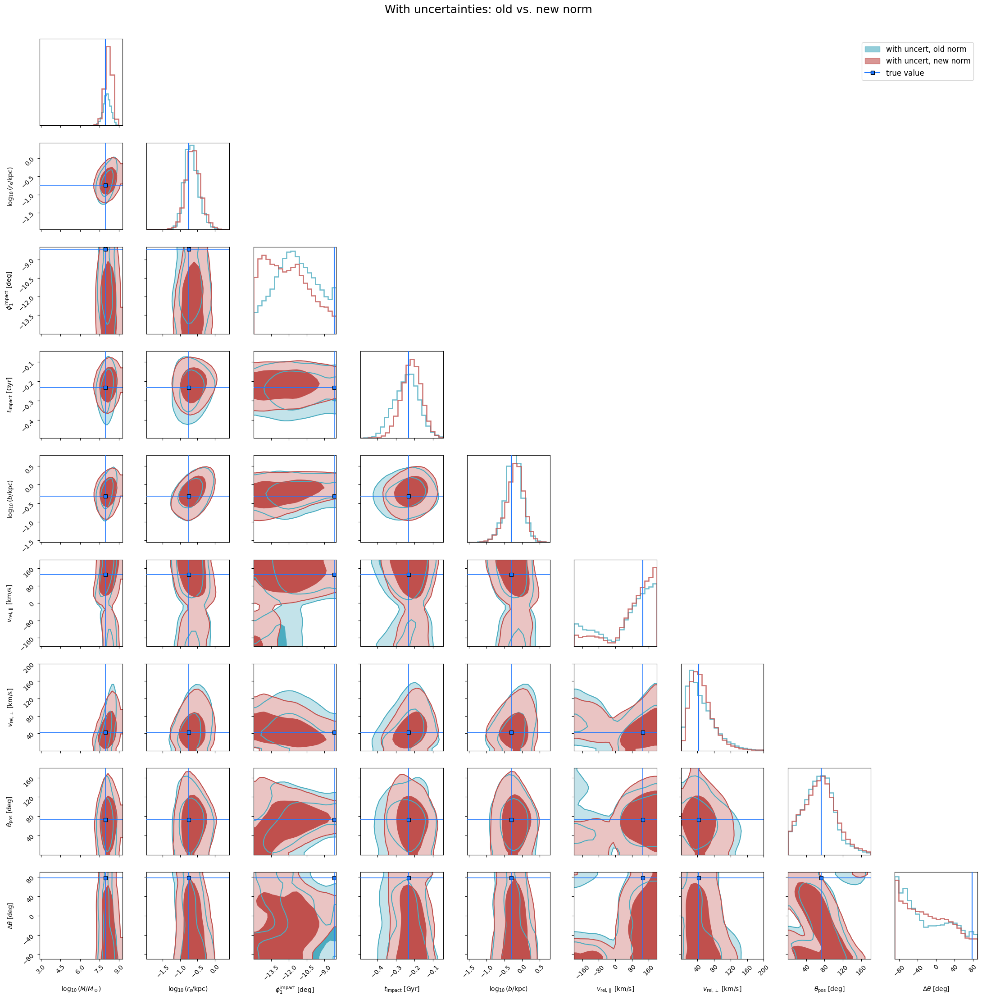

In [ ]:
# plot_comparison_corner(["with uncert, old norm", "with uncert, new norm"], title="With uncertainties: old vs. new norm")

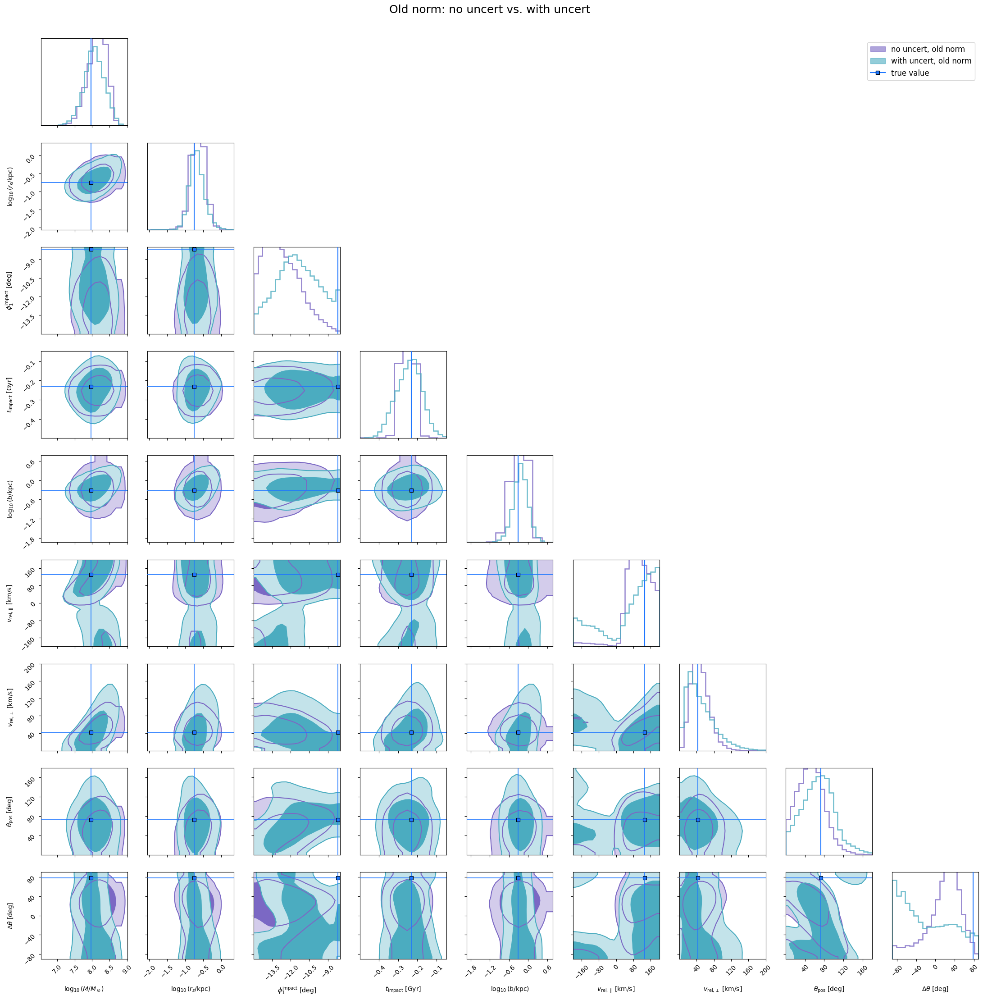

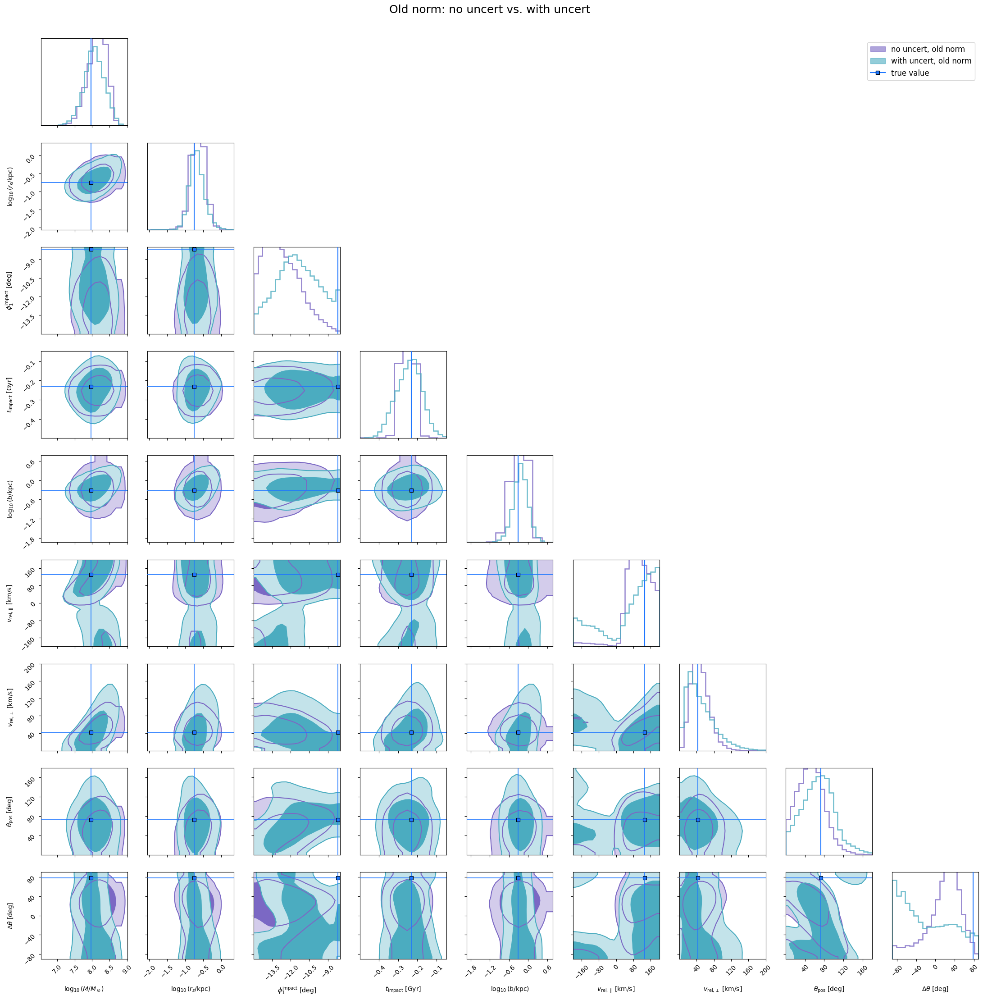

In [ ]:
# plot_comparison_corner(["no uncert, old norm", "with uncert, old norm"], title="Old norm: no uncert vs. with uncert")

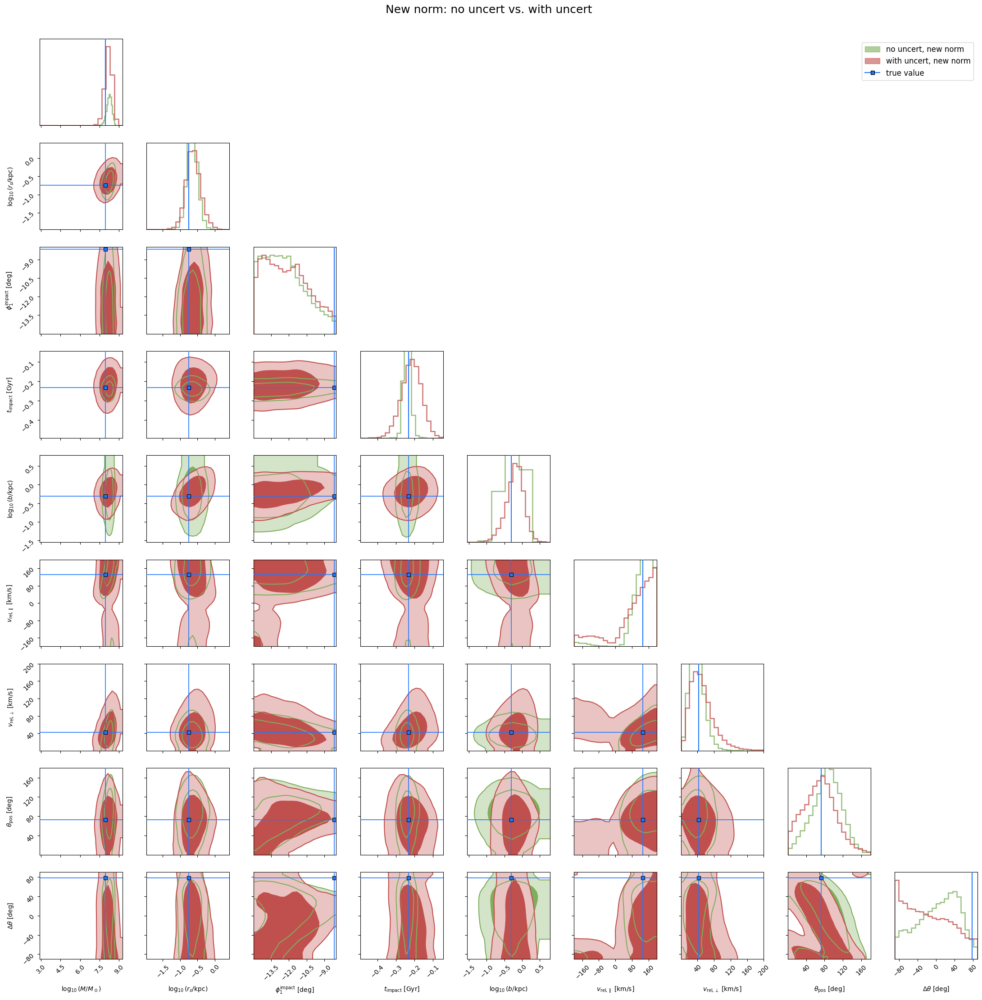

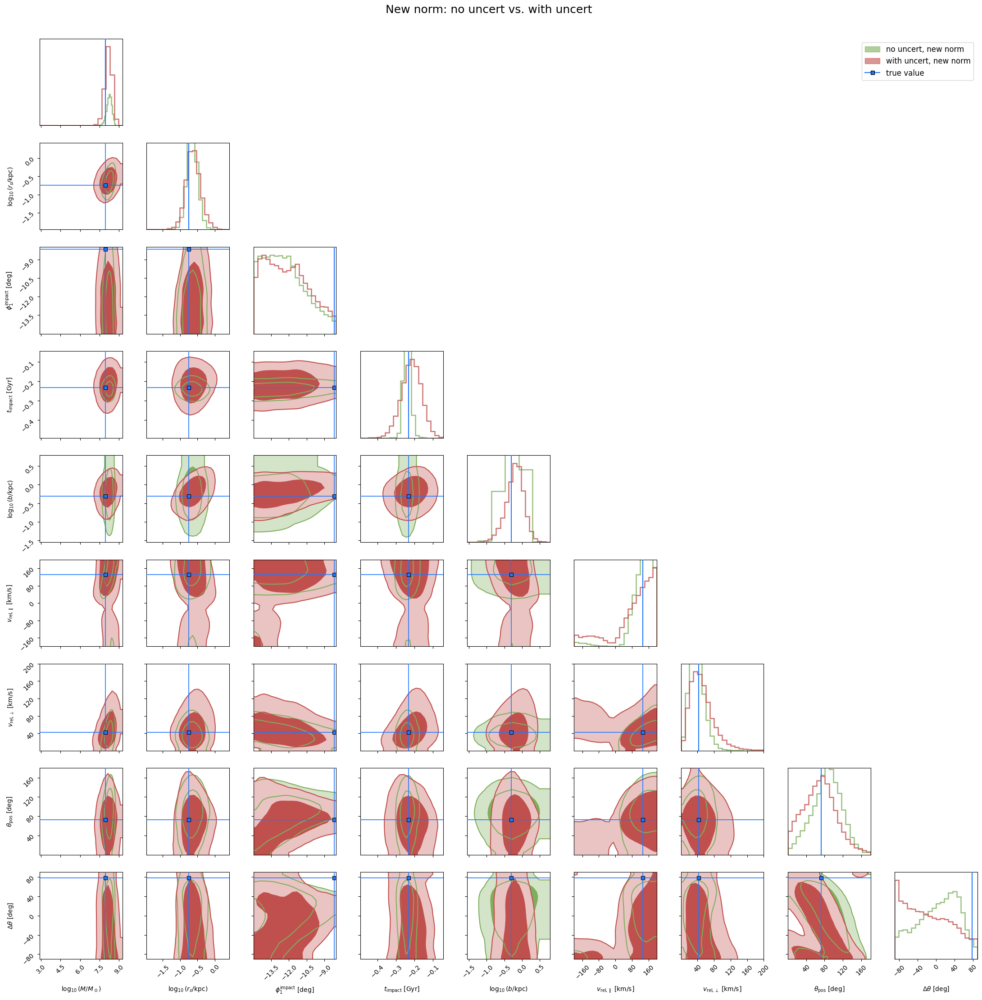

In [ ]:
# plot_comparison_corner(["no uncert, new norm", "with uncert, new norm"], title="New norm: no uncert vs. with uncert")